# Exploratory Data Analysis (EDA)
## Herd Behavior Index (HBI) Gold Layer Data

This notebook performs comprehensive exploratory data analysis on the HBI gold layer dataset, following the EDA strategy outlined in `docs/EDA_Strategy.md`.

**Dataset:** `data/gold_layer/herd_mentality_events_gold_data_v2.csv`  
**Records:** 625 historical events (1925-2025)  
**Columns:** 20 (temporal, geographic, HBI dimensions, labels, segments)

In [32]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from scipy import stats
from scipy.stats import chi2_contingency

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Suppress warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Initial Overview


In [33]:
# Load the dataset
data_path = Path("../../data/gold_layer/herd_mentality_events_gold_data_v2.csv").resolve()
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!

Dataset Shape: 625 rows × 20 columns

First few rows:


,Year,Event Name,Continent,Event Description,Country,Decade,Event Type,Trigger,Magnitude(M),Spread(S),Intensity(I),Duration(D),Outcome/Impact(R),Magnitude_label,Spread_label,Intensity_label,Duration_label,Outcome_label,Mode,Segment
0,1925,South African Rand mine strike,Africa,"In 1925, thousands of African gold‑mine workers on the Witwatersrand launched a coordinated stri...",South Africa,1920's,Social,Repression,8.0,4.0,7.0,5.0,8.0,Very High,Regional,High,Moderate,Major,Diffusive,S2 - Emotion-Driven
1,1926,Birth of Pan-African Congress,Africa,"In 1926, African intellectuals and diaspora leaders formally organized the Pan‑African Congress,...",United Kingdom,1920's,Social,Policy,6.0,9.0,5.0,3.0,9.0,Moderate-High,Continental,Moderate,Short,Transformational,Diffusive,S3 - Volatile Expansion
2,1927,Foundation of ANC Youth League (SA),Africa,"In 1927, young activists in South Africa founded the African National Congress Youth League (ANC...",South Africa,1920's,Social,Repression,4.0,6.0,6.0,4.0,7.0,Moderate-Low,National,Moderate-High,Moderate-Short,Significant,Diffusive,S1 - Aligned Expansion
3,1928,South African Black political conference,Africa,"In 1928, black political leaders from across South Africa gathered at a conference in Johannesbu...",South Africa,1920's,Social,Repression,5.0,6.0,3.0,3.0,7.0,Moderate,National,Low,Short,Significant,Diffusive,S5 - Low Energy Diffusion
4,1930,Mass migration for economic reasons in Sahel,Africa,In 1930 a severe drought combined with the global economic downturn and French colonial tax and ...,Mali,1930's,Social,Policy,7.0,8.0,8.0,6.0,7.0,High,Multi-National,Very High,Long,Significant,Diffusive,S2 - Emotion-Driven


In [34]:
# Basic dataset information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print(f"\n Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nYear Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"\nColumns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nData Types:")
print(df.dtypes)

DATASET INFORMATION

 Dataset Shape: 625 rows × 20 columns

Year Range: 1925 - 2025

Columns (20):
   1. Year
   2. Event Name
   3. Continent
   4. Event Description
   5. Country
   6. Decade
   7. Event Type
   8. Trigger
   9. Magnitude(M)
  10. Spread(S)
  11. Intensity(I)
  12. Duration(D)
  13. Outcome/Impact(R)
  14. Magnitude_label
  15. Spread_label
  16. Intensity_label
  17. Duration_label
  18. Outcome_label
  19. Mode
  20. Segment

Data Types:
Year                   int64
Event Name            object
Continent             object
Event Description     object
Country               object
Decade                object
Event Type            object
Trigger               object
Magnitude(M)         float64
Spread(S)            float64
Intensity(I)         float64
Duration(D)          float64
Outcome/Impact(R)    float64
Magnitude_label       object
Spread_label          object
Intensity_label       object
Duration_label        object
Outcome_label         object
Mode           

## 2. Data Quality Assessment

In [35]:
# Missing values check
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print("\nMissing Values Summary:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("\nNo missing values found!")

MISSING VALUES ANALYSIS

Missing Values Summary:
         Missing Count  Missing Percentage
Segment             11                1.76


In [36]:
# Validate numeric ranges (M, S, I, D, R should be 1-10)
print("=" * 80)
print("DATA VALIDATION: HBI DIMENSIONS RANGE CHECK")
print("=" * 80)

dimensions = ['Magnitude(M)', 'Spread(S)', 'Intensity(I)', 'Duration(D)', 'Outcome/Impact(R)']

for dim in dimensions:
    min_val = df[dim].min()
    max_val = df[dim].max()
    out_of_range = ((df[dim] < 1) | (df[dim] > 10)).sum()
    
    print(f"\n{dim}:")
    print(f"  Range: {min_val} - {max_val}")
    if out_of_range > 0:
        print(f" {out_of_range} values out of range (1-10)")
    else:
        print(f"All values within valid range (1-10)")

DATA VALIDATION: HBI DIMENSIONS RANGE CHECK

Magnitude(M):
  Range: 2.0 - 9.0
All values within valid range (1-10)

Spread(S):
  Range: 3.0 - 10.0
All values within valid range (1-10)

Intensity(I):
  Range: 3.0 - 10.0
All values within valid range (1-10)

Duration(D):
  Range: 1.0 - 10.0
All values within valid range (1-10)

Outcome/Impact(R):
  Range: 3.0 - 10.0
All values within valid range (1-10)


In [37]:
# Check for duplicate records
print("=" * 80)
print("DUPLICATE RECORDS CHECK")
print("=" * 80)

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_count}")

if duplicate_count == 0:
    print("No duplicate records found!")
else:
    print(f"Found {duplicate_count} duplicate records")

# Check for duplicate event names
duplicate_names = df[df.duplicated(subset=['Event Name'], keep=False)]['Event Name'].value_counts()
if len(duplicate_names) > 0:
    print(f"\nFound {len(duplicate_names)} events with duplicate names:")
    print(duplicate_names.head(10))
else:
    print("\nAll event names are unique")

DUPLICATE RECORDS CHECK

Duplicate rows: 0
No duplicate records found!

Found 3 events with duplicate names:
Event Name
Foundation of ANC Youth League (SA)           2
US presidential election mass mobilization    2
Cronulla riots (Australia)                    2
Name: count, dtype: int64


## 3. Descriptive Statistics

In [38]:
# Overall descriptive statistics for HBI dimensions
print("=" * 80)
print("DESCRIPTIVE STATISTICS: HBI DIMENSIONS")
print("=" * 80)

dimensions = ['Magnitude(M)', 'Spread(S)', 'Intensity(I)', 'Duration(D)', 'Outcome/Impact(R)']
stats_df = df[dimensions].describe()

# Add additional statistics
stats_df.loc['skewness'] = df[dimensions].skew()
stats_df.loc['kurtosis'] = df[dimensions].kurtosis()

print("\nSummary Statistics:")
print(stats_df.round(2))

DESCRIPTIVE STATISTICS: HBI DIMENSIONS

Summary Statistics:
          Magnitude(M)  Spread(S)  Intensity(I)  Duration(D)  \
count           625.00     625.00        625.00       625.00   
mean              6.82       6.25          6.76         5.40   
std               1.19       1.36          1.12         2.20   
min               2.00       3.00          3.00         1.00   
25%               6.00       6.00          6.00         4.00   
50%               7.00       6.00          7.00         5.00   
75%               8.00       6.00          7.00         7.00   
max               9.00      10.00         10.00        10.00   
skewness         -0.62       0.13         -0.61         0.31   
kurtosis          0.41       0.82          0.53        -0.64   

          Outcome/Impact(R)  
count                625.00  
mean                   7.51  
std                    1.14  
min                    3.00  
25%                    7.00  
50%                    8.00  
75%                    8.

In [39]:
# Categorical fields summary
print("=" * 80)
print("CATEGORICAL FIELDS SUMMARY")
print("=" * 80)

categorical_cols = ['Event Type', 'Trigger', 'Continent', 'Decade', 'Mode', 'Segment']

for col in categorical_cols:
    print(f"\n{col}:")
    value_counts = df[col].value_counts()
    print(value_counts)
    print(f"  Unique values: {df[col].nunique()}")

CATEGORICAL FIELDS SUMMARY

Event Type:
Event Type
Social        606
Industrial      7
Financial       6
Technology      4
Consumer        2
Name: count, dtype: int64
  Unique values: 5

Trigger:
Trigger
Policy         220
Repression     172
Fear           155
Opportunity     38
Hype            25
Greed           15
Name: count, dtype: int64
  Unique values: 6

Continent:
Continent
Australia/Oceania    105
Africa               104
Asia                 104
Europe               104
North America        104
South America        104
Name: count, dtype: int64
  Unique values: 6

Decade:
Decade
2000's    66
1980's    66
1960's    66
1940's    62
1930's    60
1970's    60
1950's    60
2010's    60
1990's    60
2020's    36
1920's    29
Name: count, dtype: int64
  Unique values: 11

Mode:
Mode
Diffusive     597
Co-present     28
Name: count, dtype: int64
  Unique values: 2

Segment:
Segment
S2 - Emotion-Driven          264
S4 - Persistent Friction     149
S1 - Aligned Expansion       148
S3 - 

## 4. Univariate Analysis - HBI Dimensions Distribution

Distribution plot saved to dashboards/hbi_dimensions_distribution.png


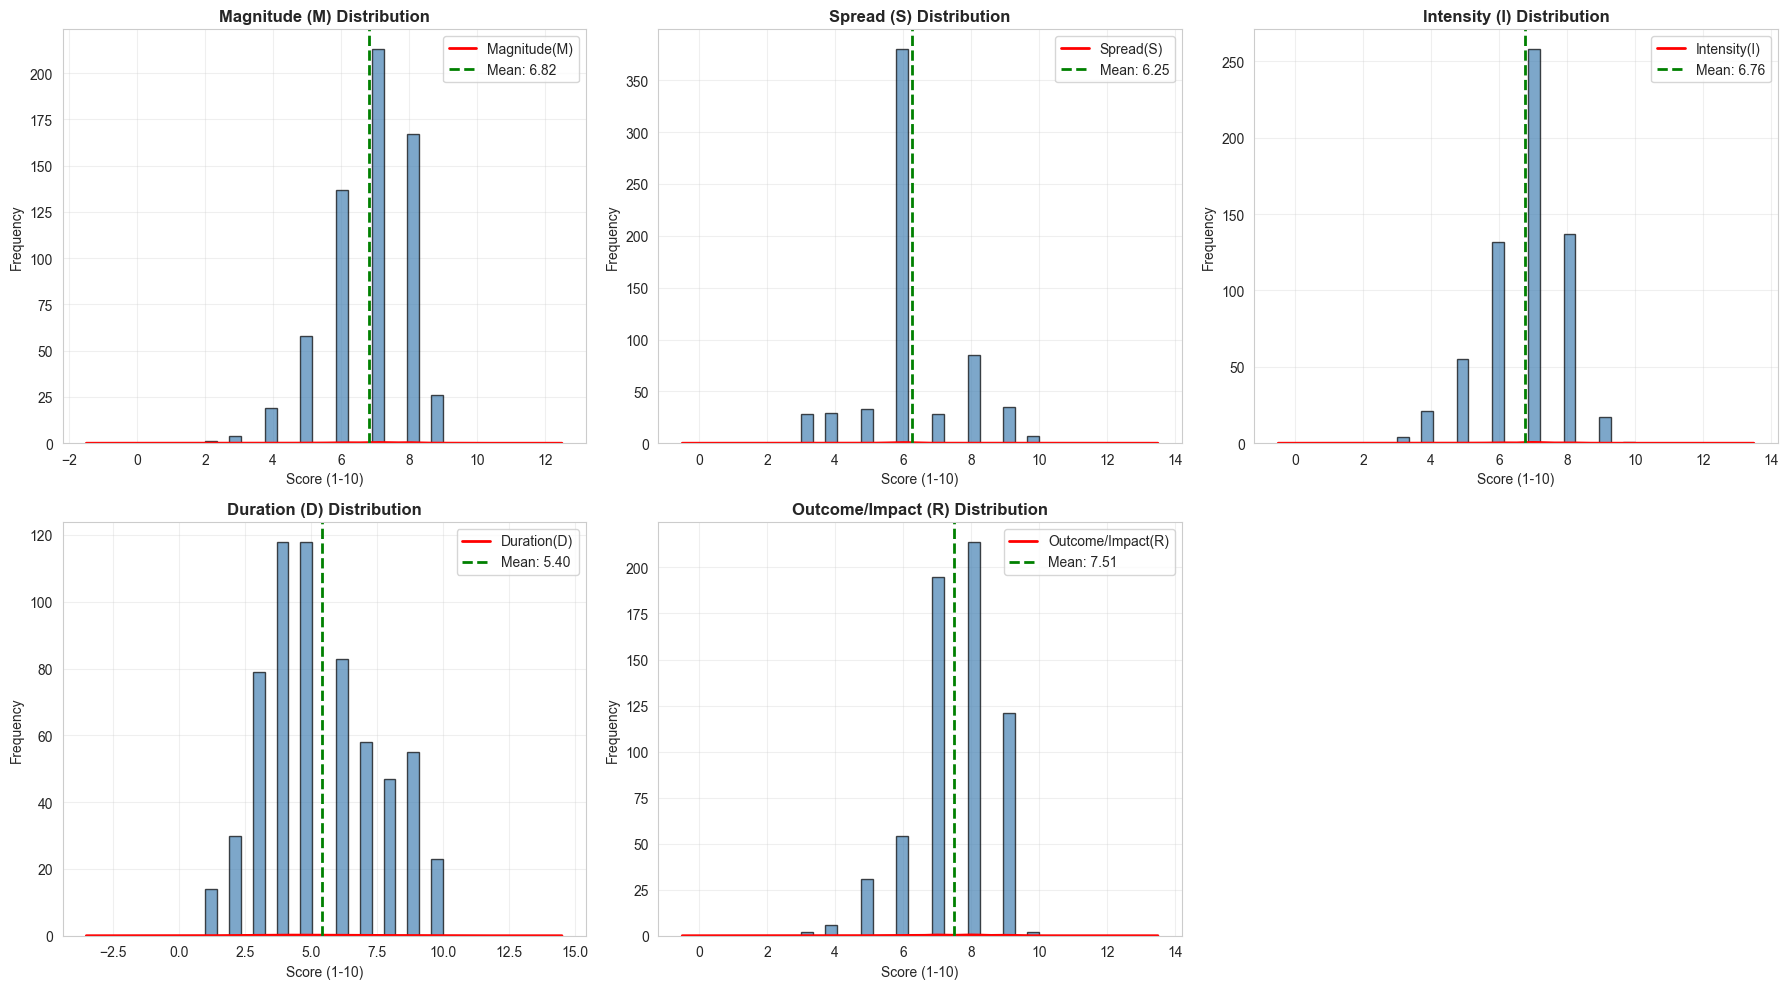

In [40]:
# Distribution plots for HBI dimensions
dimensions = ['Magnitude(M)', 'Spread(S)', 'Intensity(I)', 'Duration(D)', 'Outcome/Impact(R)']
dim_labels = ['Magnitude (M)', 'Spread (S)', 'Intensity (I)', 'Duration (D)', 'Outcome/Impact (R)']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (dim, label) in enumerate(zip(dimensions, dim_labels)):
    ax = axes[idx]
    
    # Histogram with density curve
    df[dim].hist(bins=20, alpha=0.7, ax=ax, color='steelblue', edgecolor='black')
    df[dim].plot.density(ax=ax, color='red', linewidth=2)
    
    # Add mean line
    mean_val = df[dim].mean()
    ax.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    
    ax.set_title(f'{label} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Score (1-10)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide the last subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_distribution.png', dpi=300, bbox_inches='tight')
print("Distribution plot saved to dashboards/hbi_dimensions_distribution.png")
plt.show()

### 4.1 Outlier Detection

In [41]:
# Outlier detection using Z-score method
print("=" * 80)
print("OUTLIER DETECTION: Z-SCORE METHOD (|z| > 3)")
print("=" * 80)

from scipy import stats

zscore_summary = []

for dim in dimensions:
    z_scores = np.abs(stats.zscore(df[dim]))
    outliers = df[z_scores > 3]
    outliers_count = len(outliers)
    
    zscore_summary.append({
        'Dimension': dim,
        'Outliers Count': outliers_count,
        'Percentage': (outliers_count / len(df)) * 100
    })
    
    print(f"\n{dim}:")
    print(f"  Outliers (|z| > 3): {outliers_count} ({(outliers_count / len(df)) * 100:.2f}%)")

zscore_df = pd.DataFrame(zscore_summary)
print("\n" + "=" * 80)
print("Z-SCORE OUTLIER SUMMARY")
print("=" * 80)
print(zscore_df.round(2))

OUTLIER DETECTION: Z-SCORE METHOD (|z| > 3)

Magnitude(M):
  Outliers (|z| > 3): 5 (0.80%)

Spread(S):
  Outliers (|z| > 3): 0 (0.00%)

Intensity(I):
  Outliers (|z| > 3): 4 (0.64%)

Duration(D):
  Outliers (|z| > 3): 0 (0.00%)

Outcome/Impact(R):
  Outliers (|z| > 3): 8 (1.28%)

Z-SCORE OUTLIER SUMMARY
           Dimension  Outliers Count  Percentage
0       Magnitude(M)               5        0.80
1          Spread(S)               0        0.00
2       Intensity(I)               4        0.64
3        Duration(D)               0        0.00
4  Outcome/Impact(R)               8        1.28


✓ Violin plot by Trigger saved to dashboards/hbi_dimensions_violin_trigger.png


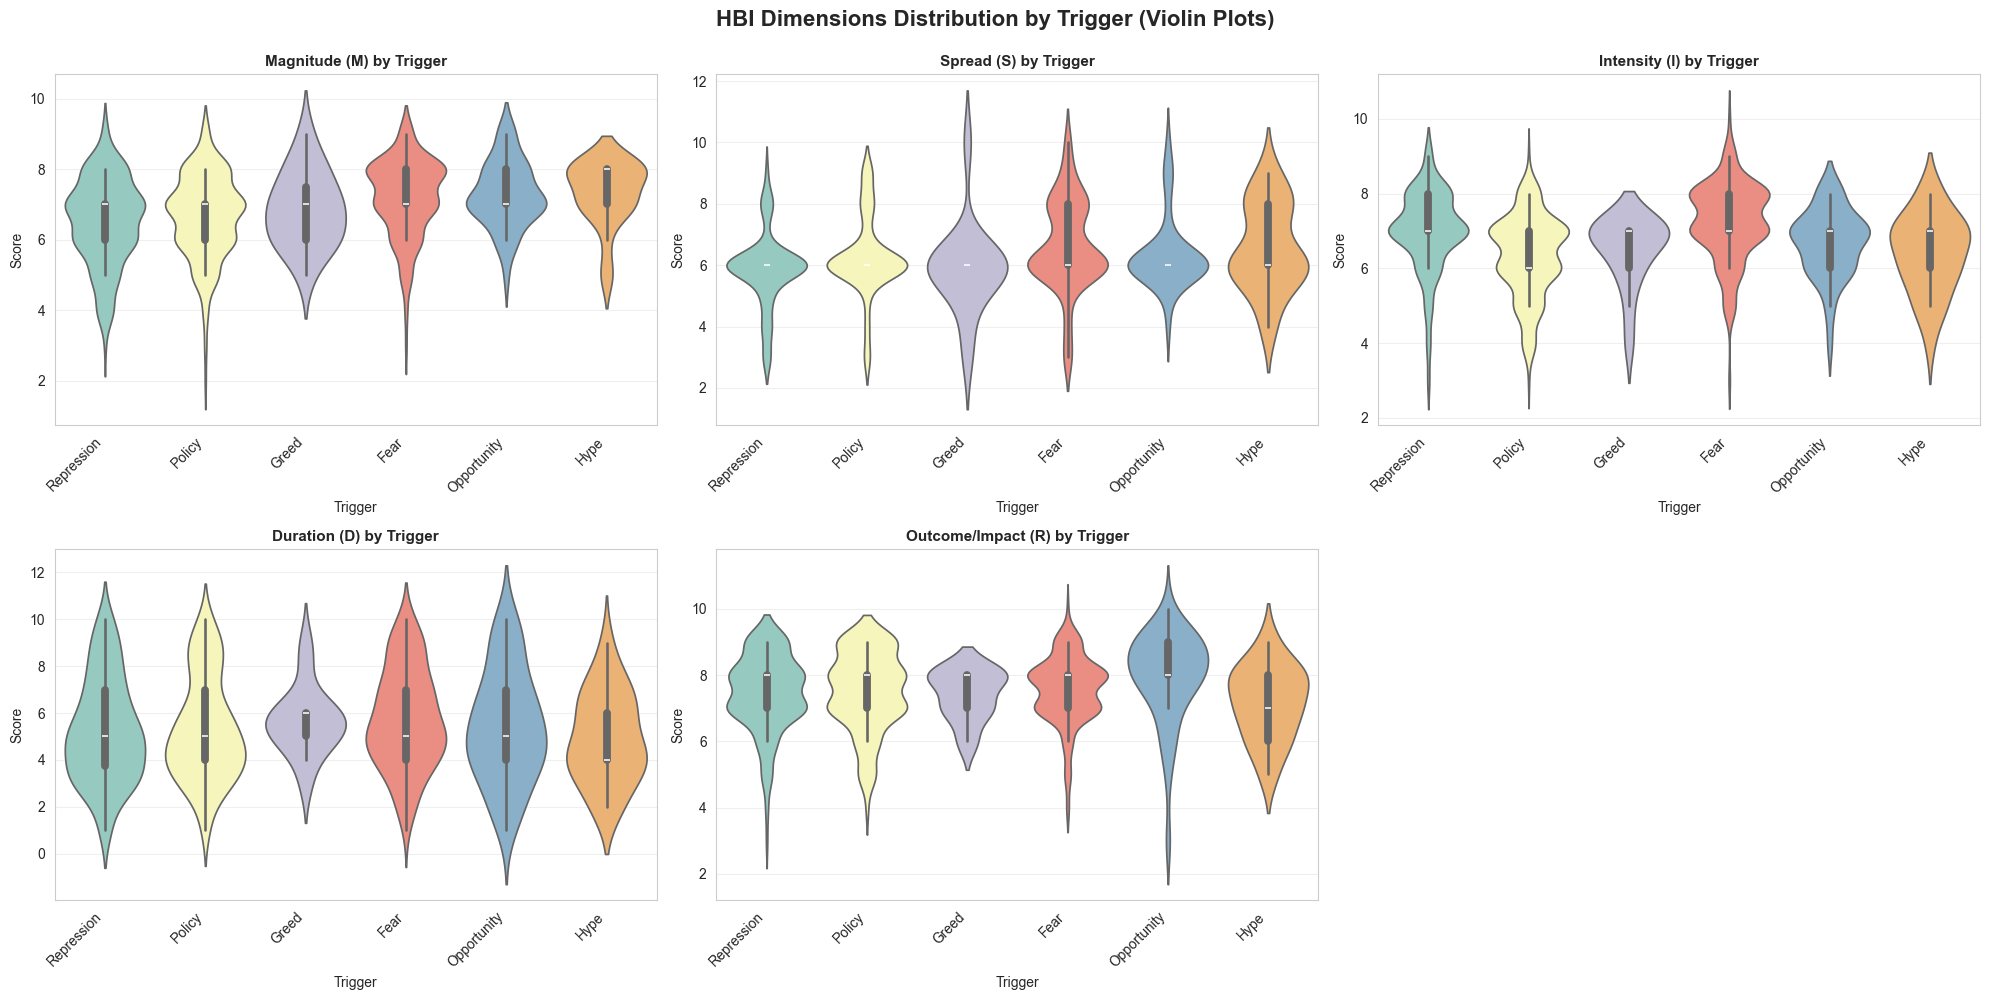

In [42]:
# Violin plots: HBI dimensions by Trigger
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for idx, (dim, label) in enumerate(zip(dimensions, dim_labels)):
    ax = axes[idx]
    sns.violinplot(data=df, x='Trigger', y=dim, ax=ax, palette='Set3')
    ax.set_title(f'{label} by Trigger', fontsize=11, fontweight='bold')
    ax.set_xlabel('Trigger', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].axis('off')

plt.suptitle('HBI Dimensions Distribution by Trigger (Violin Plots)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_violin_trigger.png', dpi=300, bbox_inches='tight')
print("✓ Violin plot by Trigger saved to dashboards/hbi_dimensions_violin_trigger.png")
plt.show()


## 8. Correlation Analysis


SEGMENT CROSS-TABULATION

SEGMENT × EVENT TYPE

 Event Type                 Consumer  Financial  Industrial  Social  \
Segment                                                              
S1 - Aligned Expansion            0          0           1     147   
S2 - Emotion-Driven               0          3           3     256   
S3 - Volatile Expansion           0          1           0      47   
S4 - Persistent Friction          2          2           3     141   
S5 - Low Energy Diffusion         0          0           0       4   
All                               2          6           7     595   

Event Type                 Technology  All  
Segment                                     
S1 - Aligned Expansion              0  148  
S2 - Emotion-Driven                 2  264  
S3 - Volatile Expansion             1   49  
S4 - Persistent Friction            1  149  
S5 - Low Energy Diffusion           0    4  
All                                 4  614  

SEGMENT × TRIGGER

 Trigger  

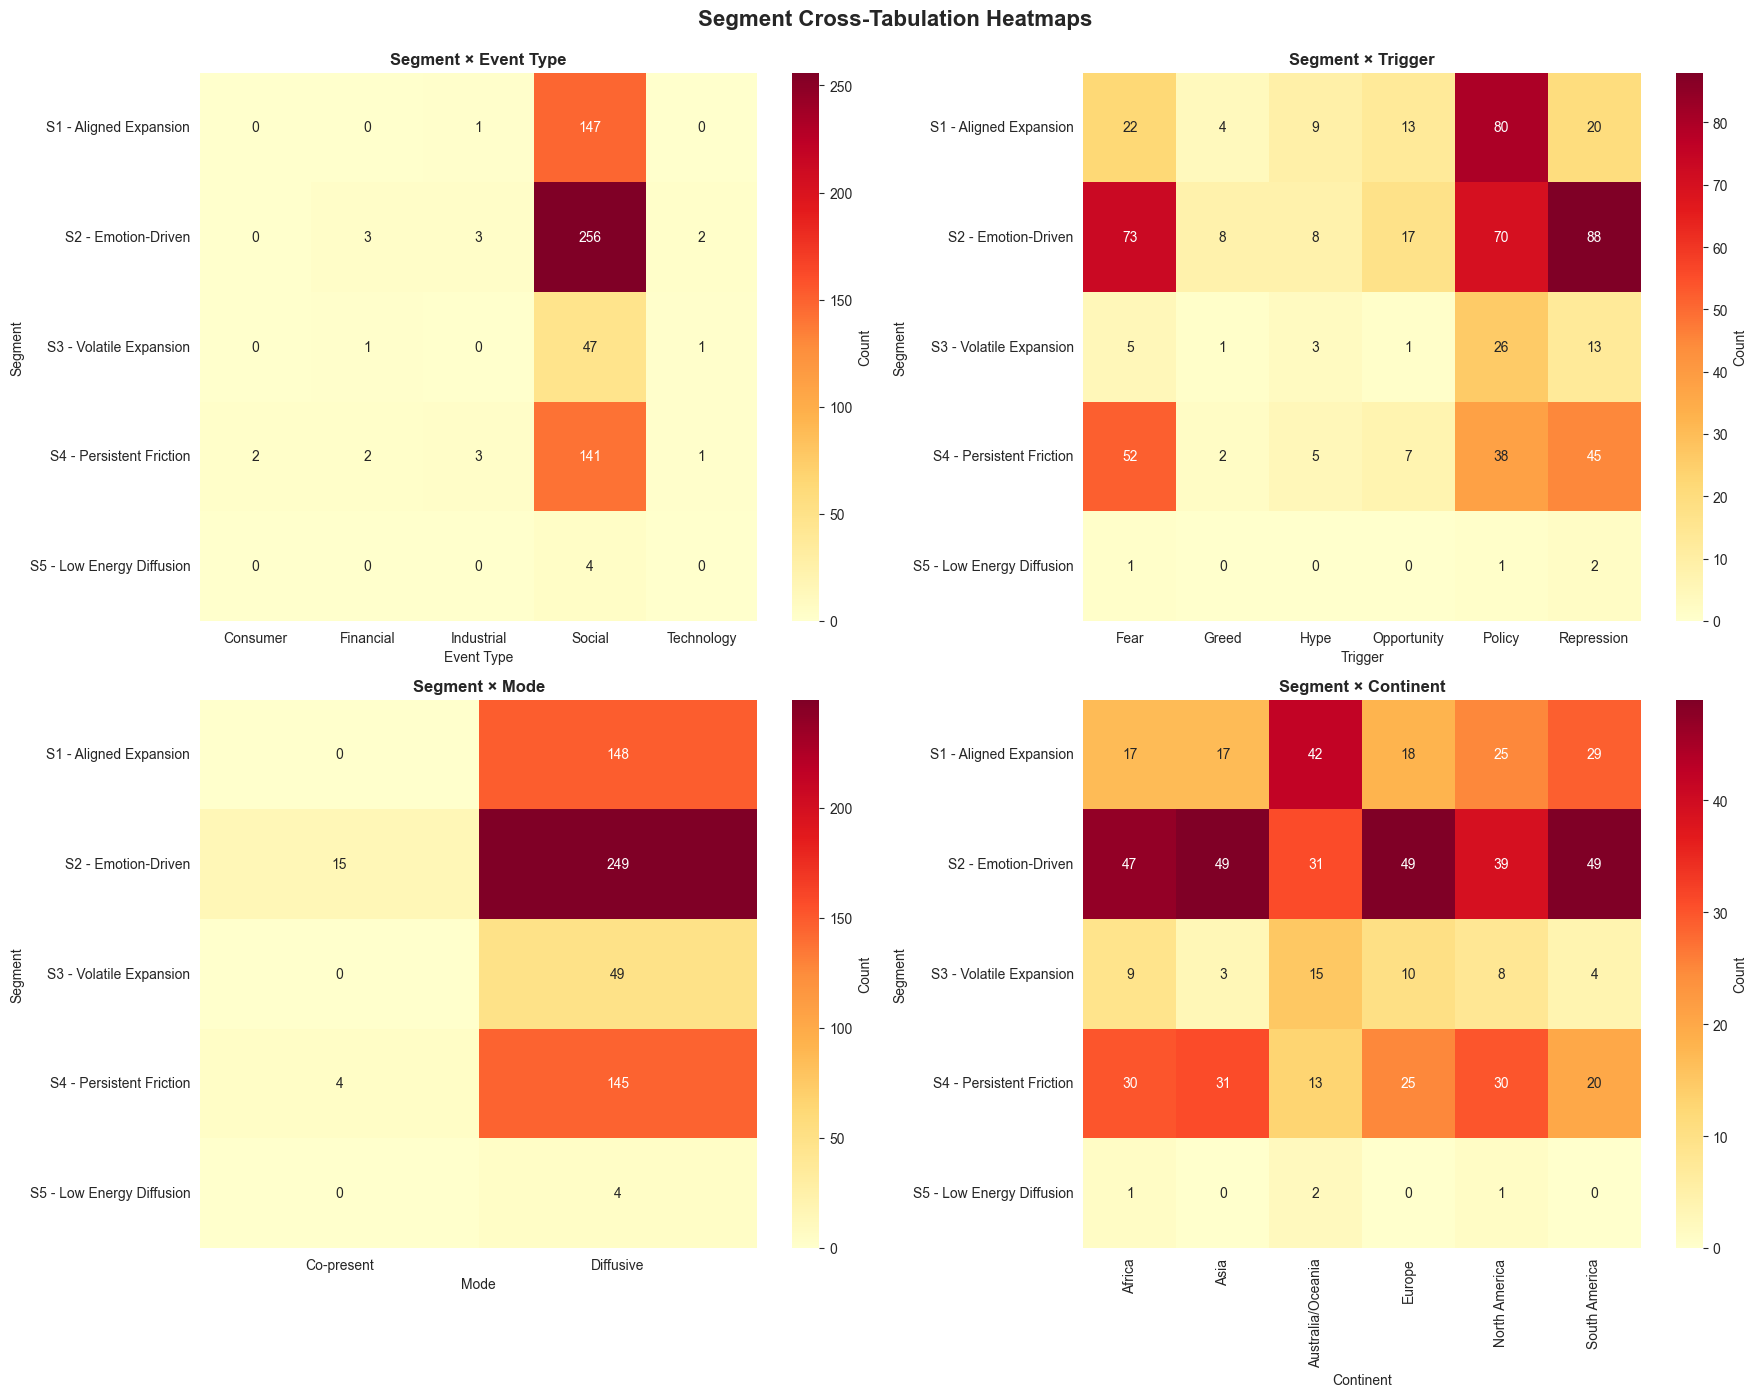

In [43]:
# Segment cross-tabulation with Event Type, Trigger, Mode, and Continent
print("=" * 80)
print("SEGMENT CROSS-TABULATION")
print("=" * 80)

# Segment × Event Type
print("\n" + "=" * 80)
print("SEGMENT × EVENT TYPE")
print("=" * 80)
segment_event = pd.crosstab(df['Segment'], df['Event Type'], margins=True)
print("\n", segment_event)

# Segment × Trigger
print("\n" + "=" * 80)
print("SEGMENT × TRIGGER")
print("=" * 80)
segment_trigger = pd.crosstab(df['Segment'], df['Trigger'], margins=True)
print("\n", segment_trigger)

# Segment × Mode
print("\n" + "=" * 80)
print("SEGMENT × MODE")
print("=" * 80)
segment_mode = pd.crosstab(df['Segment'], df['Mode'], margins=True)
print("\n", segment_mode)

# Segment × Continent
print("\n" + "=" * 80)
print("SEGMENT × CONTINENT")
print("=" * 80)
segment_continent = pd.crosstab(df['Segment'], df['Continent'], margins=True)
print("\n", segment_continent)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Segment × Event Type heatmap
sns.heatmap(pd.crosstab(df['Segment'], df['Event Type']), 
            annot=True, fmt='d', cmap='YlOrRd', ax=axes[0, 0], cbar_kws={'label': 'Count'})
axes[0, 0].set_title('Segment × Event Type', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Event Type', fontsize=10)
axes[0, 0].set_ylabel('Segment', fontsize=10)

# Segment × Trigger heatmap
sns.heatmap(pd.crosstab(df['Segment'], df['Trigger']), 
            annot=True, fmt='d', cmap='YlOrRd', ax=axes[0, 1], cbar_kws={'label': 'Count'})
axes[0, 1].set_title('Segment × Trigger', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Trigger', fontsize=10)
axes[0, 1].set_ylabel('Segment', fontsize=10)

# Segment × Mode heatmap
sns.heatmap(pd.crosstab(df['Segment'], df['Mode']), 
            annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_title('Segment × Mode', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Mode', fontsize=10)
axes[1, 0].set_ylabel('Segment', fontsize=10)

# Segment × Continent heatmap
sns.heatmap(pd.crosstab(df['Segment'], df['Continent']), 
            annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 1], cbar_kws={'label': 'Count'})
axes[1, 1].set_title('Segment × Continent', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Continent', fontsize=10)
axes[1, 1].set_ylabel('Segment', fontsize=10)

plt.suptitle('Segment Cross-Tabulation Heatmaps', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../../dashboards/segment_crosstab_heatmaps.png', dpi=300, bbox_inches='tight')
print("\n✓ Segment cross-tabulation heatmaps saved to dashboards/segment_crosstab_heatmaps.png")
plt.show()

### 9.2 Event Type × Trigger × Dimensions Interaction

Box plot saved to dashboards/hbi_dimensions_boxplots.png


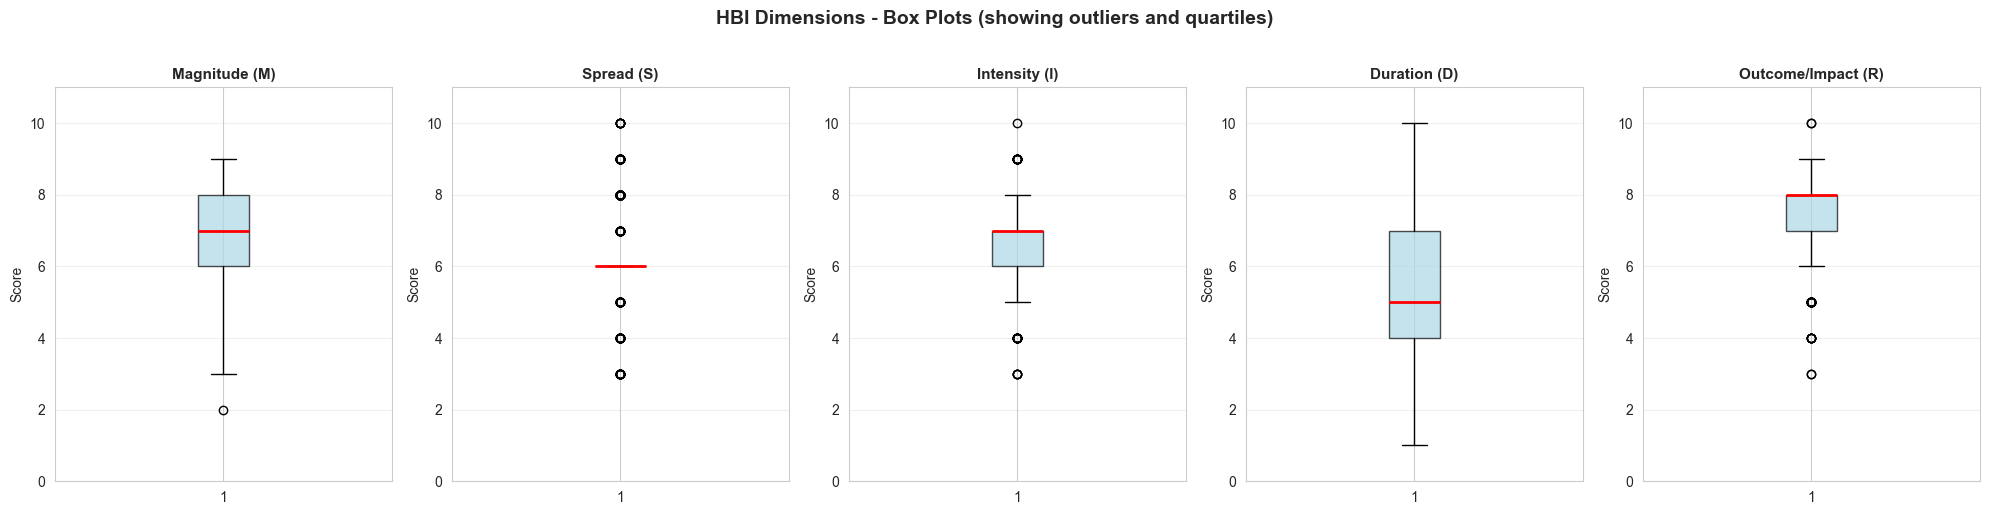

In [44]:
# Box plots for HBI dimensions
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for idx, (dim, label) in enumerate(zip(dimensions, dim_labels)):
    ax = axes[idx]
    bp = ax.boxplot(df[dim], vert=True, patch_artist=True, 
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    
    ax.set_title(f'{label}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 11)

plt.suptitle('HBI Dimensions - Box Plots (showing outliers and quartiles)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_boxplots.png', dpi=300, bbox_inches='tight')
print("Box plot saved to dashboards/hbi_dimensions_boxplots.png")
plt.show()

## 5. Temporal Analysis

Temporal distribution plot saved to dashboards/temporal_distribution.png


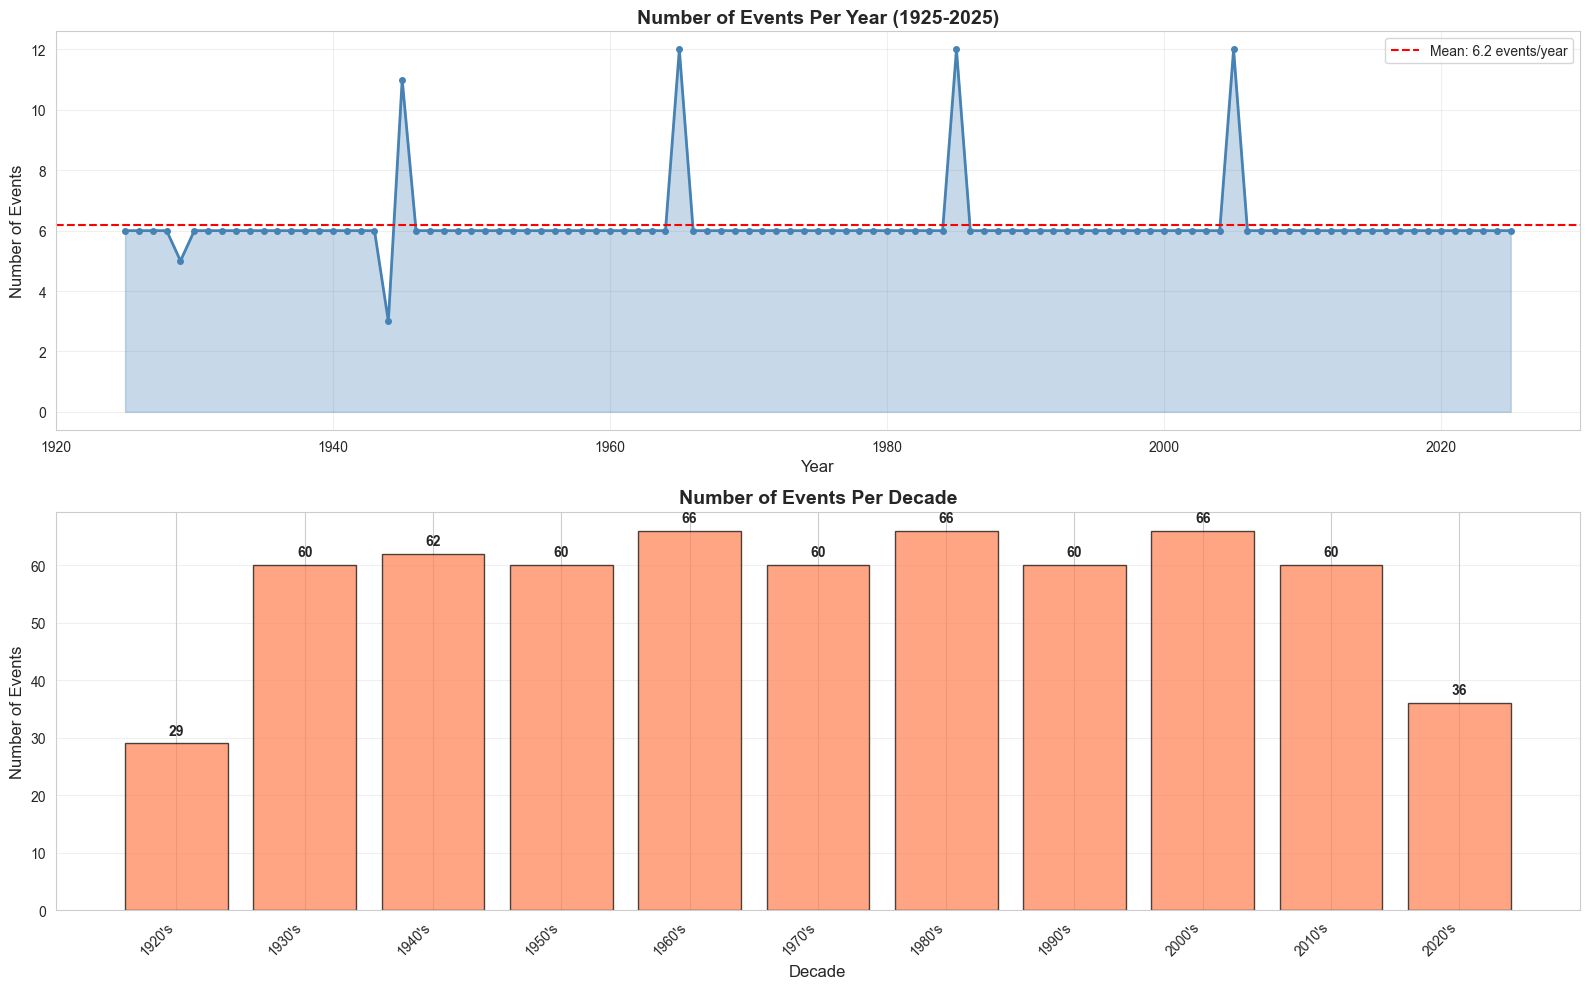


Events per decade summary:
Decade
1920's    29
1930's    60
1940's    62
1950's    60
1960's    66
1970's    60
1980's    66
1990's    60
2000's    66
2010's    60
2020's    36
Name: count, dtype: int64


In [45]:
# Events over time
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Line plot: Events count per year
events_per_year = df.groupby('Year').size()
axes[0].plot(events_per_year.index, events_per_year.values, 
             marker='o', linewidth=2, markersize=4, color='steelblue')
axes[0].fill_between(events_per_year.index, events_per_year.values, alpha=0.3, color='steelblue')
axes[0].set_title('Number of Events Per Year (1925-2025)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Events', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(events_per_year.mean(), color='red', linestyle='--', 
                label=f'Mean: {events_per_year.mean():.1f} events/year')
axes[0].legend()

# Bar chart: Events per decade
events_per_decade = df['Decade'].value_counts().sort_index()
axes[1].bar(range(len(events_per_decade)), events_per_decade.values, 
            color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(events_per_decade)))
axes[1].set_xticklabels(events_per_decade.index, rotation=45, ha='right')
axes[1].set_title('Number of Events Per Decade', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Decade', fontsize=12)
axes[1].set_ylabel('Number of Events', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(events_per_decade.values):
    axes[1].text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../../dashboards/temporal_distribution.png', dpi=300, bbox_inches='tight')
print("Temporal distribution plot saved to dashboards/temporal_distribution.png")
plt.show()

print(f"\nEvents per decade summary:")
print(events_per_decade)

Temporal trends plot saved to dashboards/hbi_dimensions_temporal_trends.png


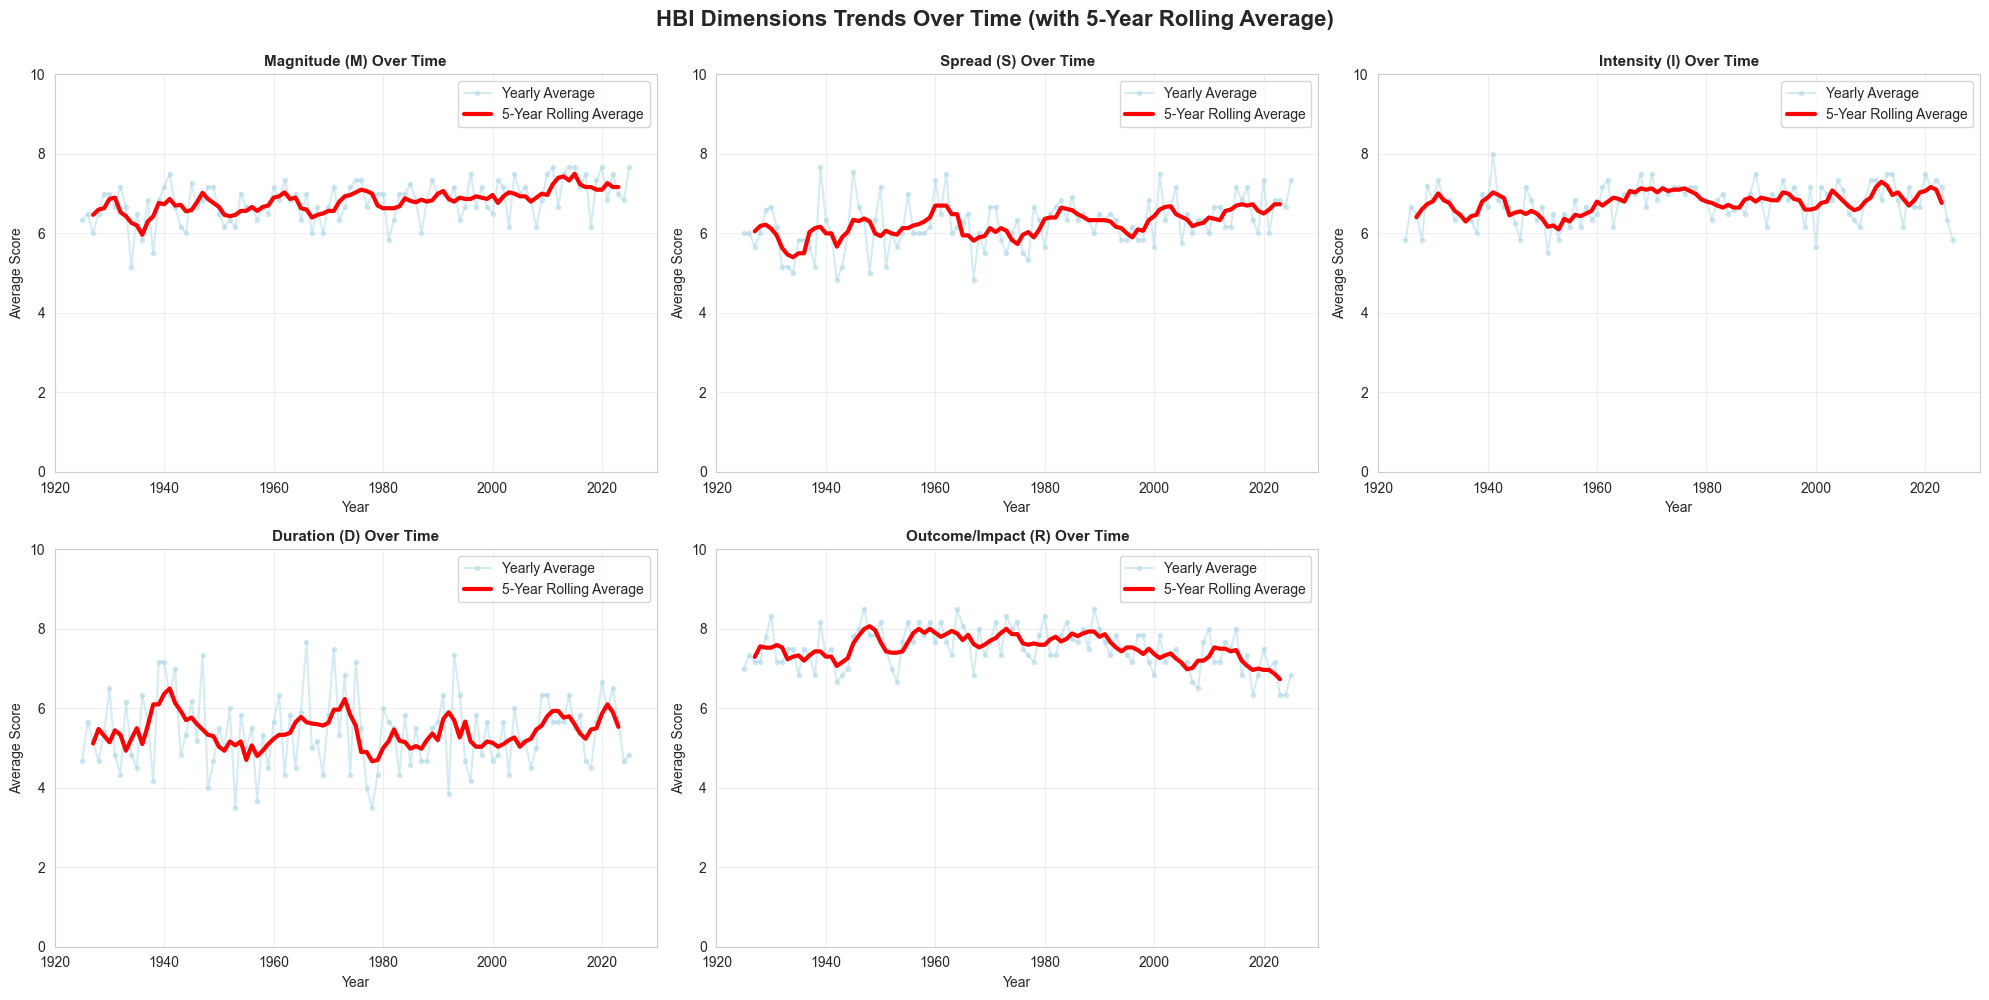

In [46]:
# Average HBI dimensions over time (rolling average)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for idx, (dim, label) in enumerate(zip(dimensions, dim_labels)):
    ax = axes[idx]
    
    # Group by year and calculate mean
    yearly_avg = df.groupby('Year')[dim].mean()
    
    # Rolling average (5-year window)
    rolling_avg = yearly_avg.rolling(window=5, center=True).mean()
    
    # Plot
    ax.plot(yearly_avg.index, yearly_avg.values, 
           marker='o', markersize=3, alpha=0.5, color='lightblue', label='Yearly Average')
    ax.plot(rolling_avg.index, rolling_avg.values, 
           linewidth=3, color='red', label='5-Year Rolling Average')
    
    ax.set_title(f'{label} Over Time', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Average Score', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 10)

axes[-1].axis('off')

plt.suptitle('HBI Dimensions Trends Over Time (with 5-Year Rolling Average)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_temporal_trends.png', dpi=300, bbox_inches='tight')
print("Temporal trends plot saved to dashboards/hbi_dimensions_temporal_trends.png")
plt.show()

### 5.3 Decade-Level Analysis

AVERAGE HBI DIMENSIONS BY DECADE

         Magnitude(M)  Spread(S)  Intensity(I)  Duration(D)  Outcome/Impact(R)
Decade                                                                       
1920's          6.45       6.03          6.38         5.10               7.28
1930's          6.42       5.83          6.63         5.45               7.43
1940's          6.94       6.15          6.69         5.85               7.58
1950's          6.50       6.12          6.32         4.98               7.70
1960's          6.68       6.26          6.92         5.52               7.77
1970's          6.93       6.08          7.10         5.43               7.75
1980's          6.79       6.45          6.76         5.17               7.83
1990's          6.90       6.20          6.83         5.47               7.57
2000's          6.88       6.36          6.73         5.17               7.17
2010's          7.28       6.52          7.00         5.58               7.28
2020's          7.25       6.

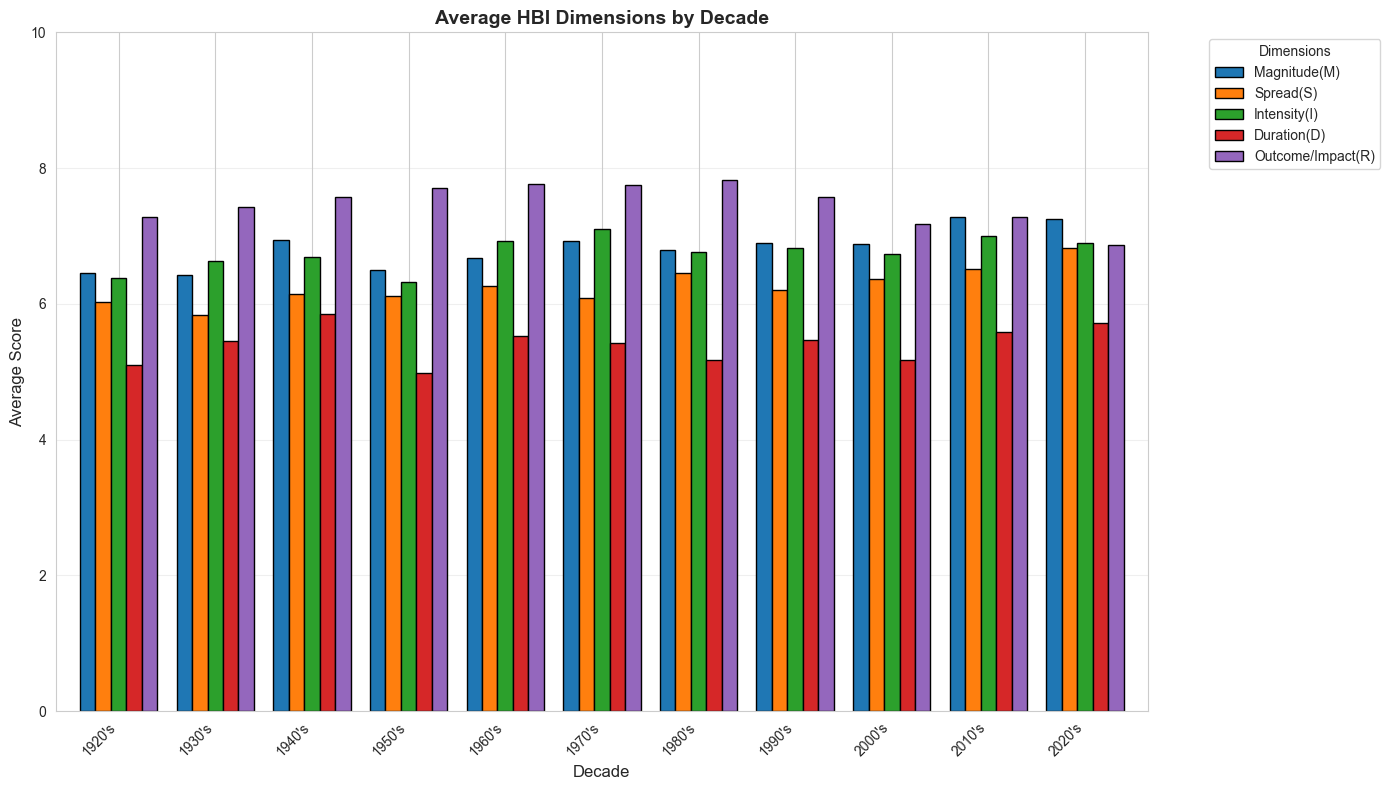

In [47]:
# Average HBI dimensions per decade
decade_stats = df.groupby('Decade')[dimensions].mean().round(2)

print("=" * 80)
print("AVERAGE HBI DIMENSIONS BY DECADE")
print("=" * 80)
print("\n", decade_stats)

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))
decade_stats.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title('Average HBI Dimensions by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.legend(title='Dimensions', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_by_decade.png', dpi=300, bbox_inches='tight')
print("\nDimensions by decade plot saved to dashboards/hbi_dimensions_by_decade.png")
plt.show()

DOMINANT EVENT TYPES AND TRIGGERS BY DECADE

1920's:
  Most Common Event Type: Social (27 events)
  Most Common Trigger: Policy (10 events)

1930's:
  Most Common Event Type: Social (56 events)
  Most Common Trigger: Repression (22 events)

1940's:
  Most Common Event Type: Social (60 events)
  Most Common Trigger: Policy (21 events)

1950's:
  Most Common Event Type: Social (57 events)
  Most Common Trigger: Policy (25 events)

1960's:
  Most Common Event Type: Social (66 events)
  Most Common Trigger: Repression (27 events)

1970's:
  Most Common Event Type: Social (58 events)
  Most Common Trigger: Repression (21 events)

1980's:
  Most Common Event Type: Social (62 events)
  Most Common Trigger: Policy (26 events)

1990's:
  Most Common Event Type: Social (60 events)
  Most Common Trigger: Fear (22 events)

2000's:
  Most Common Event Type: Social (64 events)
  Most Common Trigger: Fear (26 events)

2010's:
  Most Common Event Type: Social (60 events)
  Most Common Trigger: Policy 

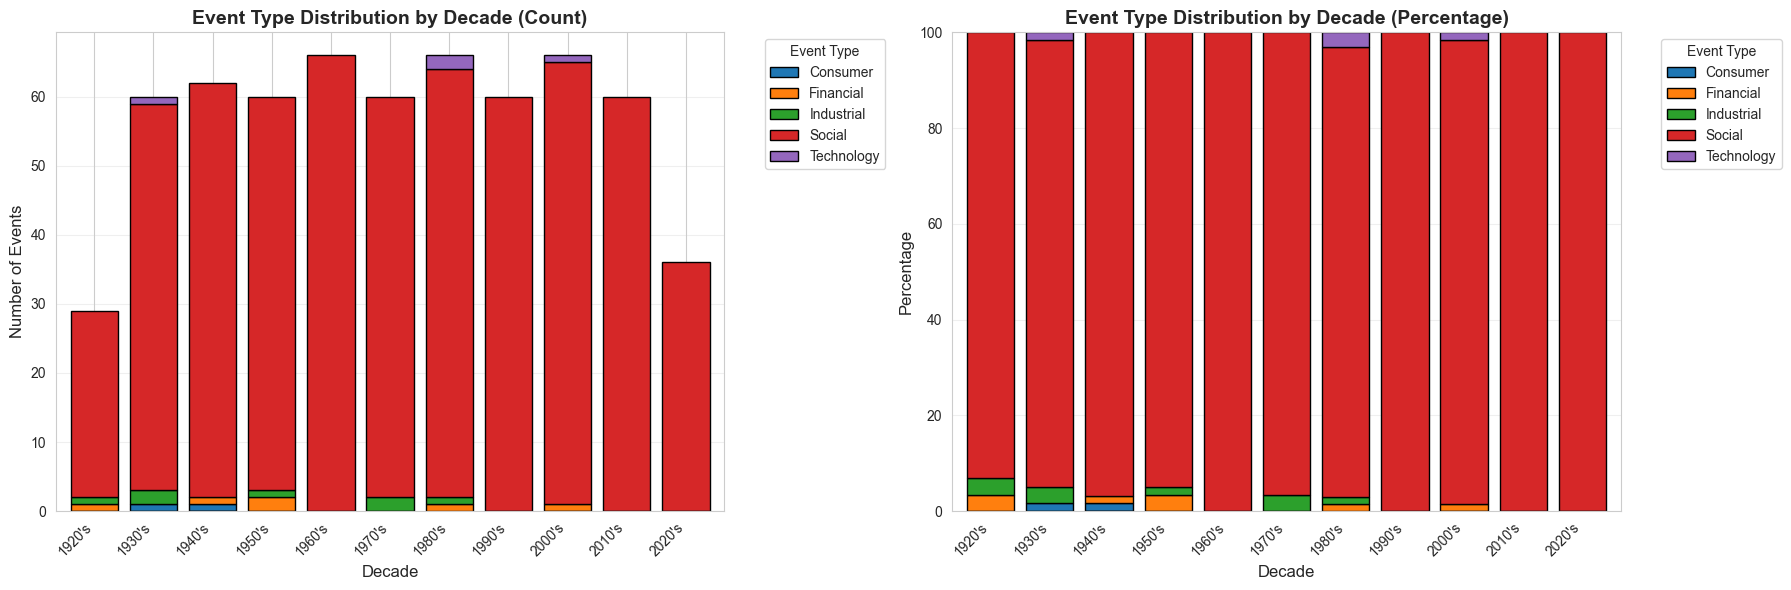

In [48]:
# Dominant Event Types and Triggers per decade
print("=" * 80)
print("DOMINANT EVENT TYPES AND TRIGGERS BY DECADE")
print("=" * 80)

decades = sorted(df['Decade'].unique())

for decade in decades:
    decade_df = df[df['Decade'] == decade]
    top_event_type = decade_df['Event Type'].value_counts().index[0]
    top_trigger = decade_df['Trigger'].value_counts().index[0]
    
    print(f"\n{decade}:")
    print(f"  Most Common Event Type: {top_event_type} ({decade_df['Event Type'].value_counts().iloc[0]} events)")
    print(f"  Most Common Trigger: {top_trigger} ({decade_df['Trigger'].value_counts().iloc[0]} events)")

# Visualization: Event Type distribution by decade
event_type_by_decade = pd.crosstab(df['Decade'], df['Event Type'])
event_type_by_decade_pct = event_type_by_decade.div(event_type_by_decade.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Stacked bar chart - counts
event_type_by_decade.plot(kind='bar', stacked=True, ax=axes[0], width=0.8, edgecolor='black')
axes[0].set_title('Event Type Distribution by Decade (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Decade', fontsize=12)
axes[0].set_ylabel('Number of Events', fontsize=12)
axes[0].legend(title='Event Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Stacked bar chart - percentages
event_type_by_decade_pct.plot(kind='bar', stacked=True, ax=axes[1], width=0.8, edgecolor='black')
axes[1].set_title('Event Type Distribution by Decade (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Decade', fontsize=12)
axes[1].set_ylabel('Percentage', fontsize=12)
axes[1].legend(title='Event Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../../dashboards/event_type_by_decade.png', dpi=300, bbox_inches='tight')
print("\nEvent Type by decade plot saved to dashboards/event_type_by_decade.png")
plt.show()

SEGMENT DISTRIBUTION BY DECADE

 Segment  S1 - Aligned Expansion  S2 - Emotion-Driven  S3 - Volatile Expansion  \
Decade                                                                          
1920's                       10                   12                        2   
1930's                       14                   24                        7   
1940's                       18                   21                        3   
1950's                       16                   20                        9   
1960's                       15                   27                        5   
1970's                       15                   28                        2   
1980's                       15                   30                        7   
1990's                       15                   26                        4   
2000's                       15                   32                        4   
2010's                        8                   26                        

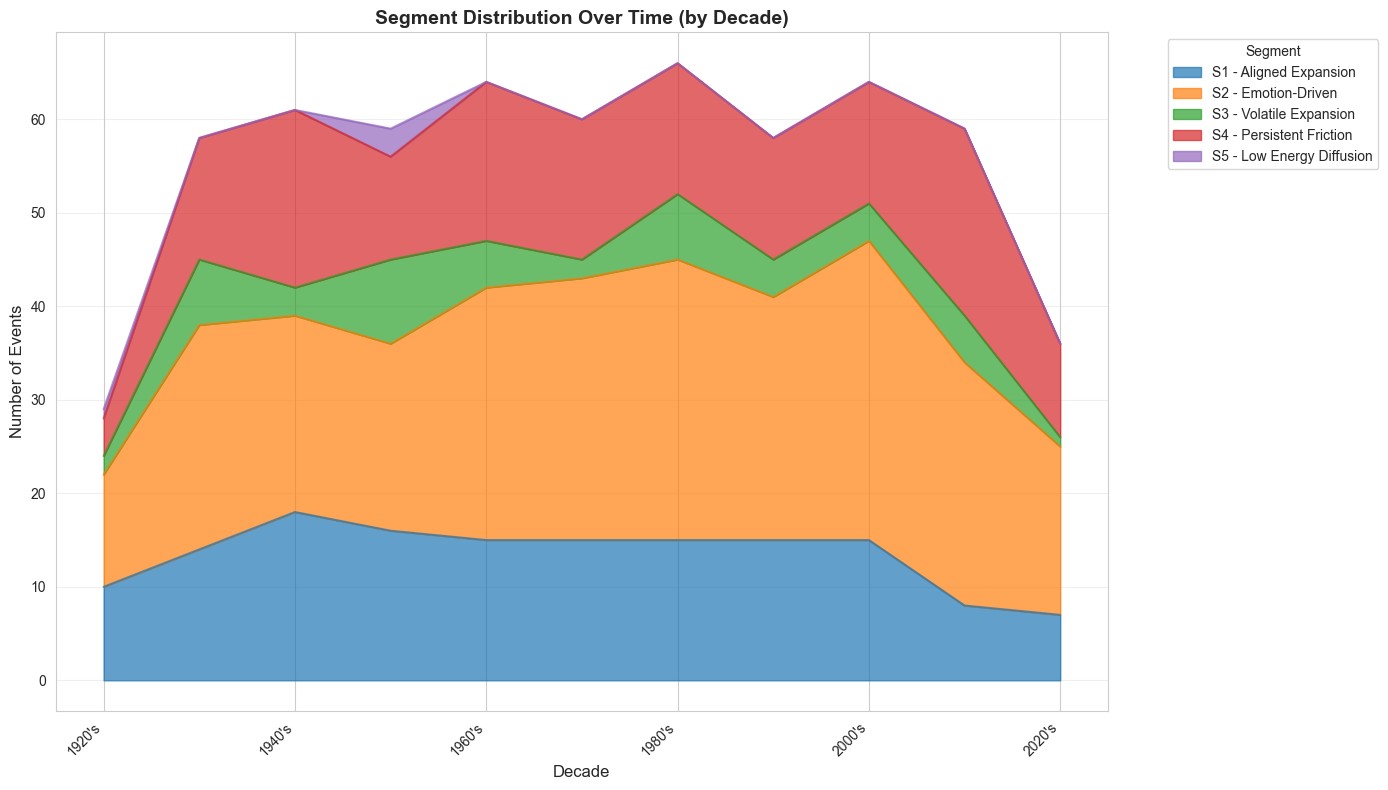

In [49]:
# Segment distribution by decade
segment_by_decade = pd.crosstab(df['Decade'], df['Segment'])

print("=" * 80)
print("SEGMENT DISTRIBUTION BY DECADE")
print("=" * 80)
print("\n", segment_by_decade)

# Visualization: Stacked area chart
fig, ax = plt.subplots(figsize=(14, 8))
segment_by_decade.plot(kind='area', ax=ax, alpha=0.7, stacked=True)
ax.set_title('Segment Distribution Over Time (by Decade)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../../dashboards/segment_distribution_by_decade.png', dpi=300, bbox_inches='tight')
print("\nSegment distribution by decade plot saved to dashboards/segment_distribution_by_decade.png")
plt.show()

## 6. Geographic Analysis

Geographic distribution plot saved to dashboards/geographic_distribution.png


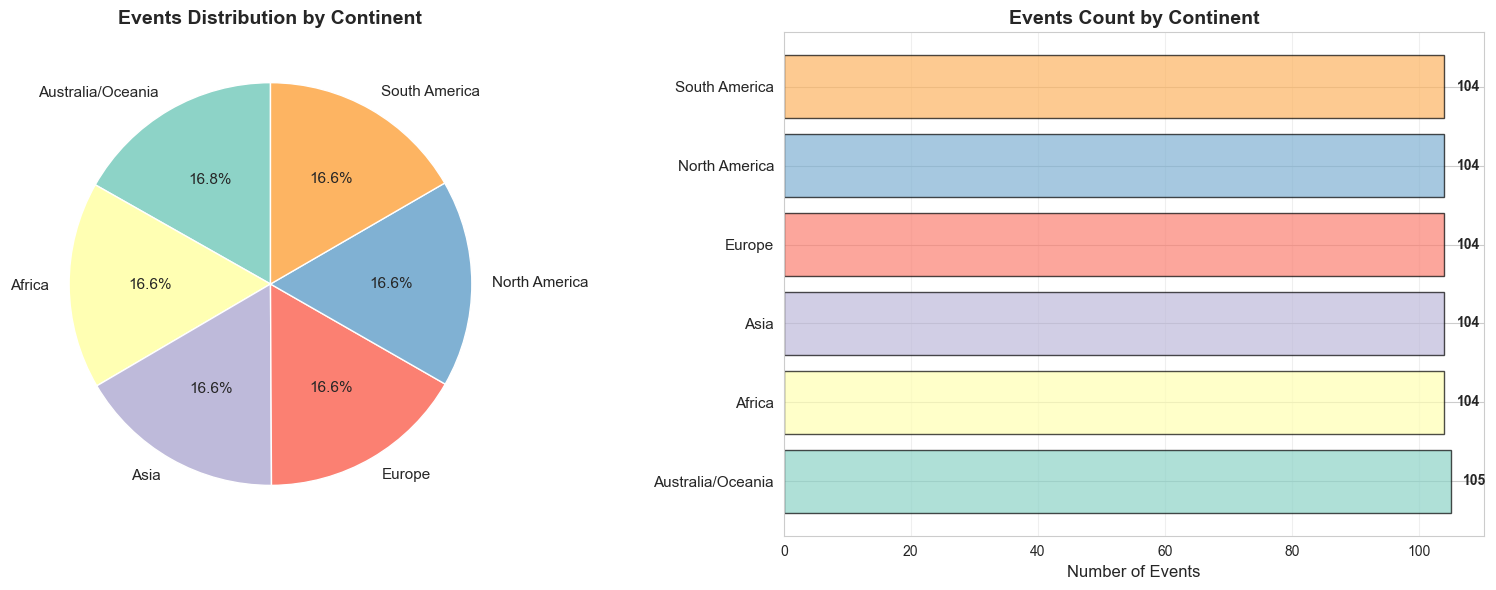


Events by continent:
Continent
Australia/Oceania    105
Africa               104
Asia                 104
Europe               104
North America        104
South America        104
Name: count, dtype: int64


In [50]:
# Events by continent
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
continent_counts = df['Continent'].value_counts()
colors = sns.color_palette("Set3", len(continent_counts))

axes[0].pie(continent_counts.values, labels=continent_counts.index, autopct='%1.1f%%',
           startangle=90, colors=colors, textprops={'fontsize': 11})
axes[0].set_title('Events Distribution by Continent', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].barh(range(len(continent_counts)), continent_counts.values, 
                   color=colors, edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(continent_counts)))
axes[1].set_yticklabels(continent_counts.index, fontsize=11)
axes[1].set_xlabel('Number of Events', fontsize=12)
axes[1].set_title('Events Count by Continent', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(continent_counts.values):
    axes[1].text(v + 2, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../../dashboards/geographic_distribution.png', dpi=300, bbox_inches='tight')
print("Geographic distribution plot saved to dashboards/geographic_distribution.png")
plt.show()

print(f"\nEvents by continent:")
print(continent_counts)

✓ Top countries plot saved to dashboards/top_countries.png


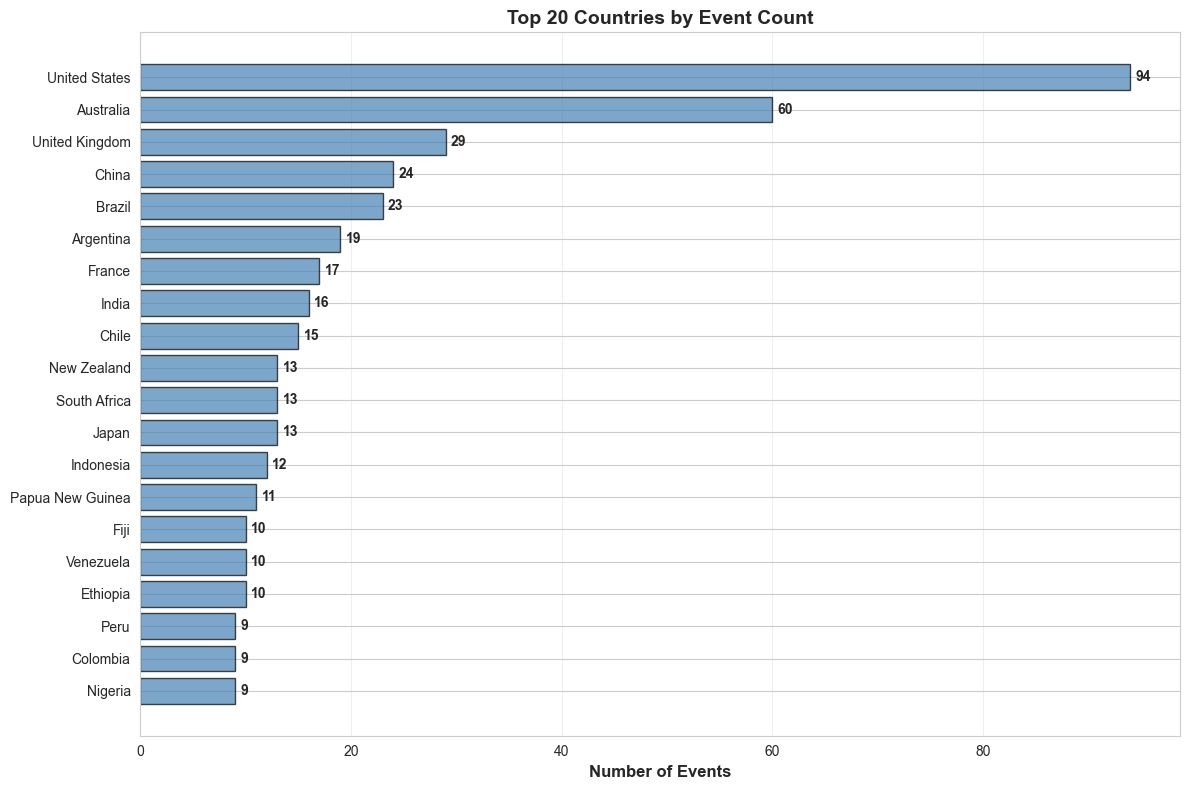


Top 10 countries:
Country
United States     94
Australia         60
United Kingdom    29
China             24
Brazil            23
Argentina         19
France            17
India             16
Chile             15
New Zealand       13
Name: count, dtype: int64


In [51]:
# Top 20 countries by event count
top_countries = df['Country'].value_counts().head(20)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_countries)), top_countries.values, 
               color='steelblue', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_countries)), top_countries.index, fontsize=10)
plt.xlabel('Number of Events', fontsize=12, fontweight='bold')
plt.title('Top 20 Countries by Event Count', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(top_countries.values):
    plt.text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../../dashboards/top_countries.png', dpi=300, bbox_inches='tight')
print("✓ Top countries plot saved to dashboards/top_countries.png")
plt.show()

print(f"\nTop 10 countries:")
print(top_countries.head(10))

AVERAGE HBI DIMENSIONS BY CONTINENT

                    Magnitude(M)  Spread(S)  Intensity(I)  Duration(D)  \
Continent                                                               
Africa                     6.72       6.51          6.91         5.62   
Asia                       7.15       5.82          7.09         5.70   
Australia/Oceania          5.94       6.09          6.13         4.95   
Europe                     7.12       6.83          6.97         5.45   
North America              7.17       6.33          6.80         5.44   
South America              6.82       5.93          6.69         5.26   

                   Outcome/Impact(R)  
Continent                             
Africa                          7.70  
Asia                            7.78  
Australia/Oceania               7.18  
Europe                          7.65  
North America                   7.51  
South America                   7.25  

Dimensions by continent plot saved to dashboards/hbi_dimensions_

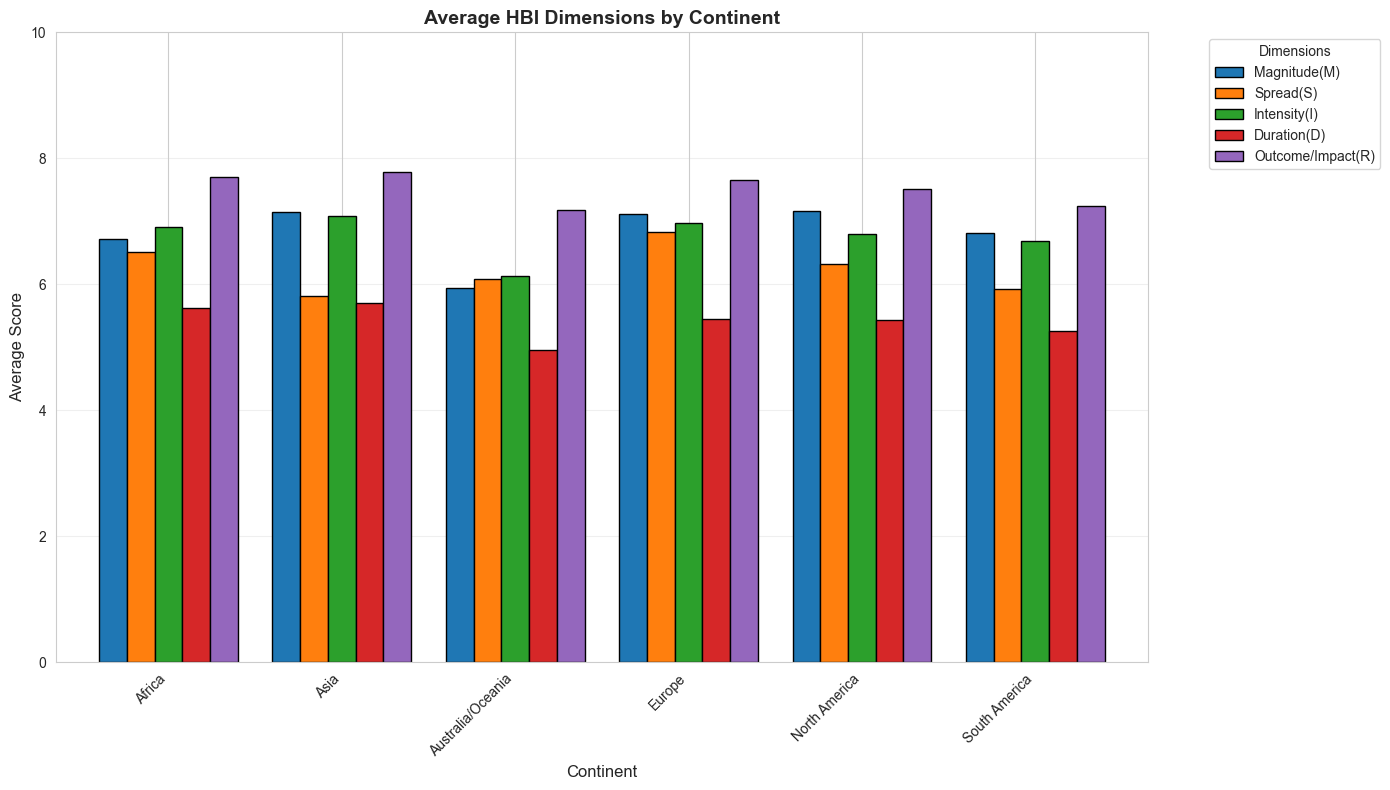

In [52]:
# Average HBI dimensions by continent
continent_stats = df.groupby('Continent')[dimensions].mean().round(2)

print("=" * 80)
print("AVERAGE HBI DIMENSIONS BY CONTINENT")
print("=" * 80)
print("\n", continent_stats)

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))
continent_stats.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title('Average HBI Dimensions by Continent', fontsize=14, fontweight='bold')
ax.set_xlabel('Continent', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.legend(title='Dimensions', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_by_continent.png', dpi=300, bbox_inches='tight')
print("\nDimensions by continent plot saved to dashboards/hbi_dimensions_by_continent.png")
plt.show()

## 7. Categorical Fields Analysis

Box plots by Event Type saved to dashboards/hbi_dimensions_boxplot_event_type.png


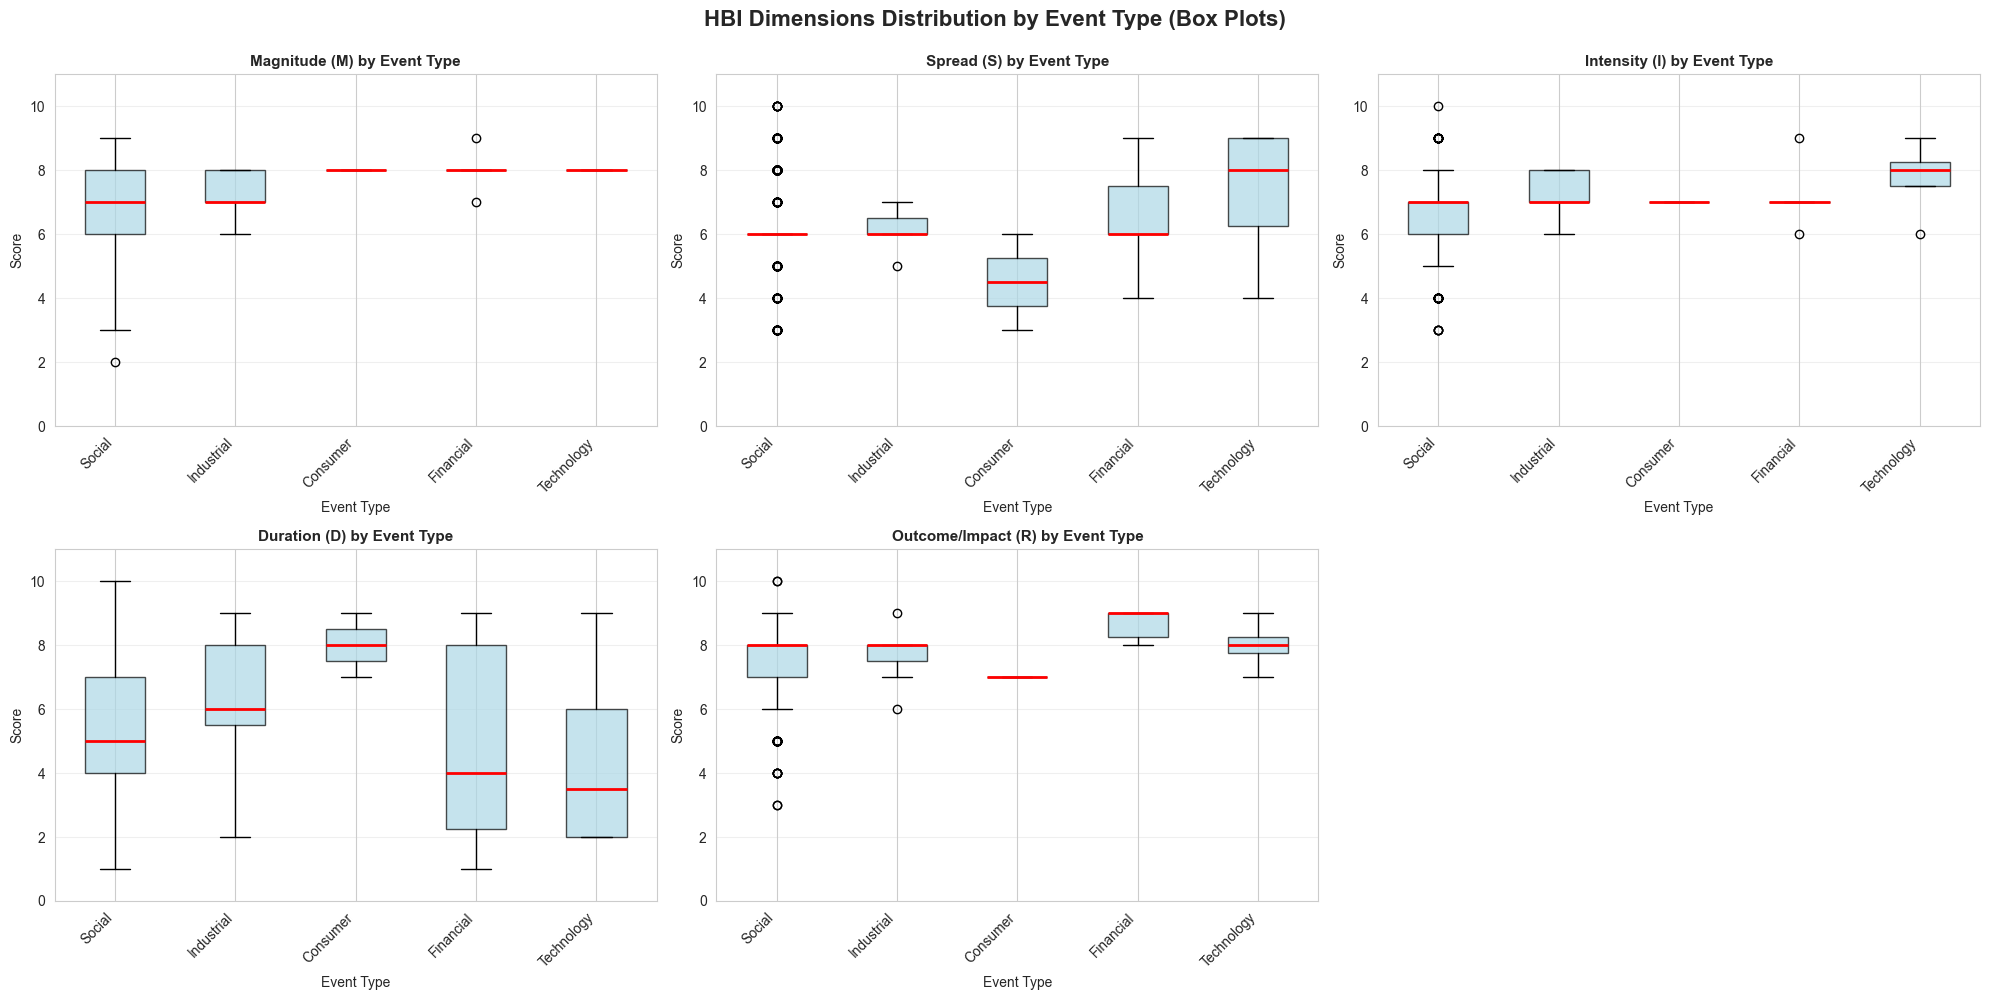

In [53]:
# Box plots for HBI dimensions by Event Type
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for idx, (dim, label) in enumerate(zip(dimensions, dim_labels)):
    ax = axes[idx]
    
    # Prepare data for box plot
    data_for_plot = [df[df['Event Type'] == et][dim].values 
                     for et in df['Event Type'].unique()]
    labels = df['Event Type'].unique()
    
    bp = ax.boxplot(data_for_plot, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    
    ax.set_title(f'{label} by Event Type', fontsize=11, fontweight='bold')
    ax.set_xlabel('Event Type', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 11)

axes[-1].axis('off')

plt.suptitle('HBI Dimensions Distribution by Event Type (Box Plots)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_boxplot_event_type.png', dpi=300, bbox_inches='tight')
print("Box plots by Event Type saved to dashboards/hbi_dimensions_boxplot_event_type.png")
plt.show()

Box plots by Trigger saved to dashboards/hbi_dimensions_boxplot_trigger.png


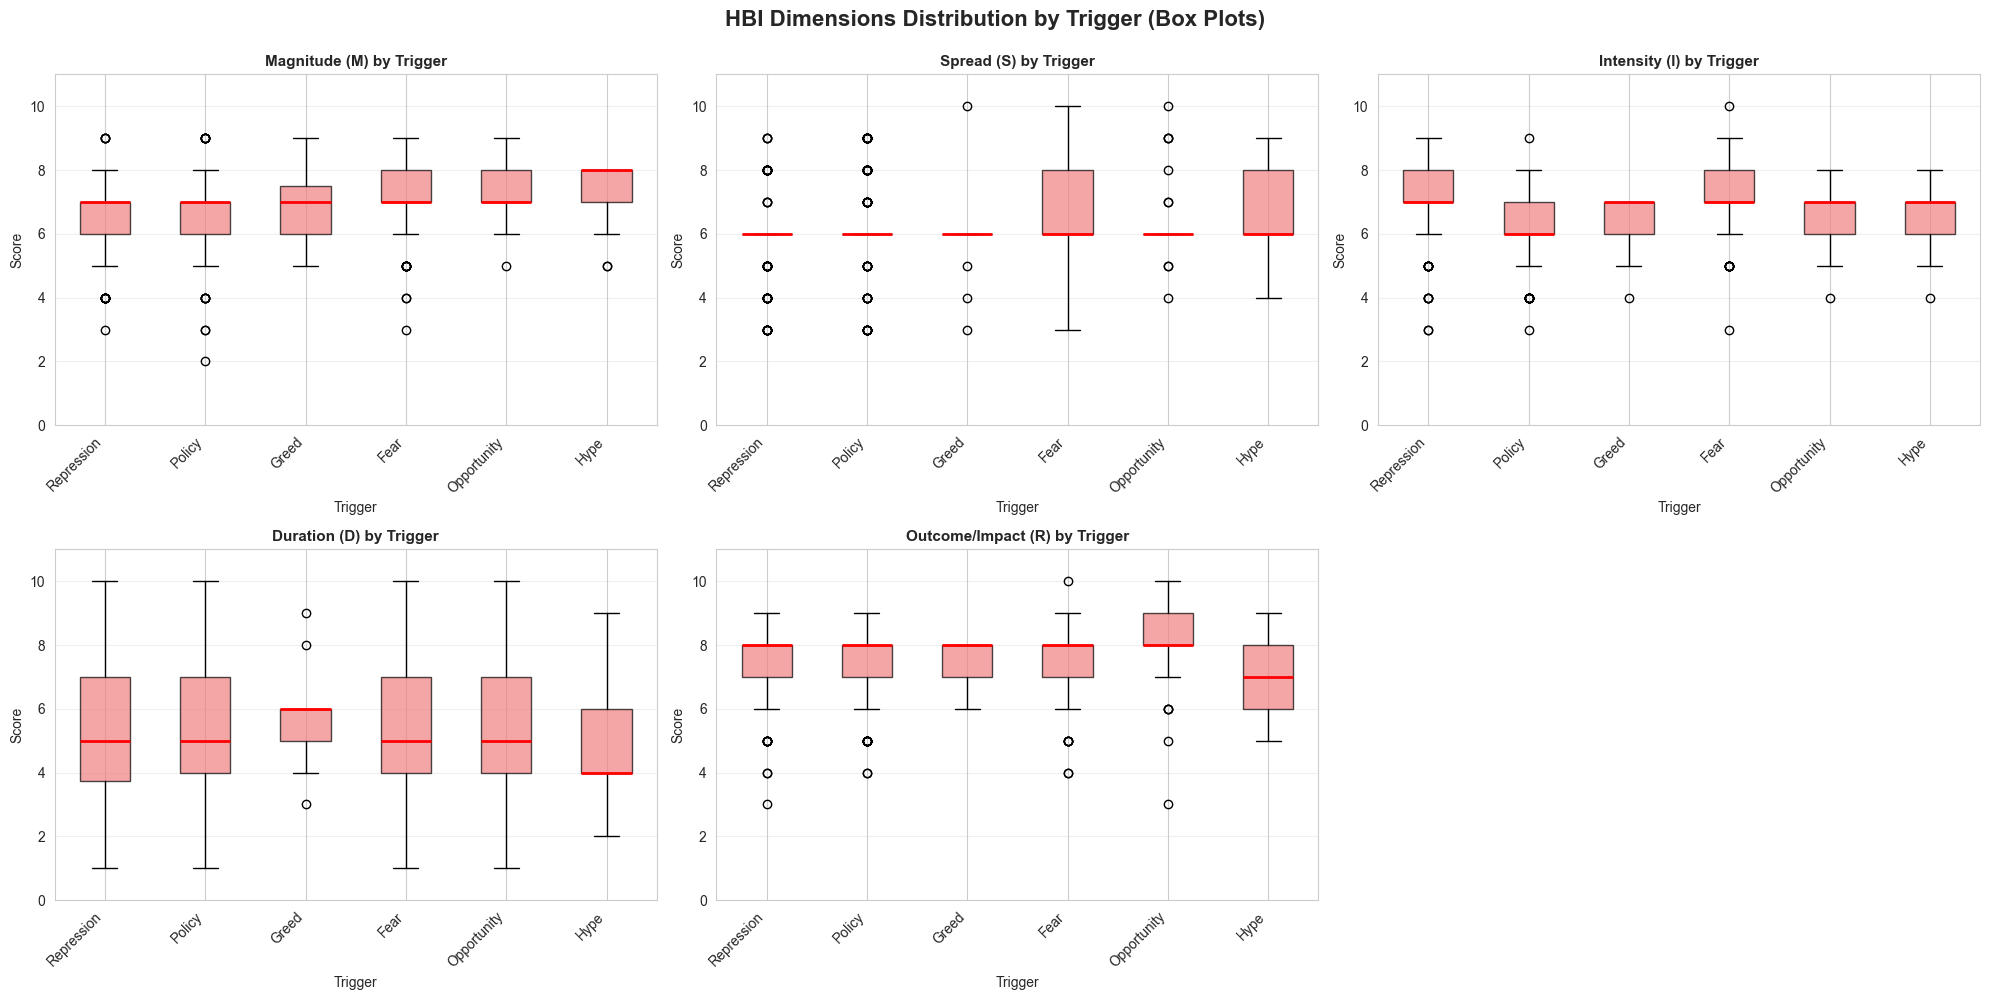

In [54]:
# Box plots for HBI dimensions by Trigger
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for idx, (dim, label) in enumerate(zip(dimensions, dim_labels)):
    ax = axes[idx]
    
    # Prepare data for box plot
    data_for_plot = [df[df['Trigger'] == tr][dim].values 
                     for tr in df['Trigger'].unique()]
    labels = df['Trigger'].unique()
    
    bp = ax.boxplot(data_for_plot, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    
    ax.set_title(f'{label} by Trigger', fontsize=11, fontweight='bold')
    ax.set_xlabel('Trigger', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 11)

axes[-1].axis('off')

plt.suptitle('HBI Dimensions Distribution by Trigger (Box Plots)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_boxplot_trigger.png', dpi=300, bbox_inches='tight')
print("Box plots by Trigger saved to dashboards/hbi_dimensions_boxplot_trigger.png")
plt.show()

✓ Event Type and Trigger plot saved to dashboards/event_type_trigger_distribution.png


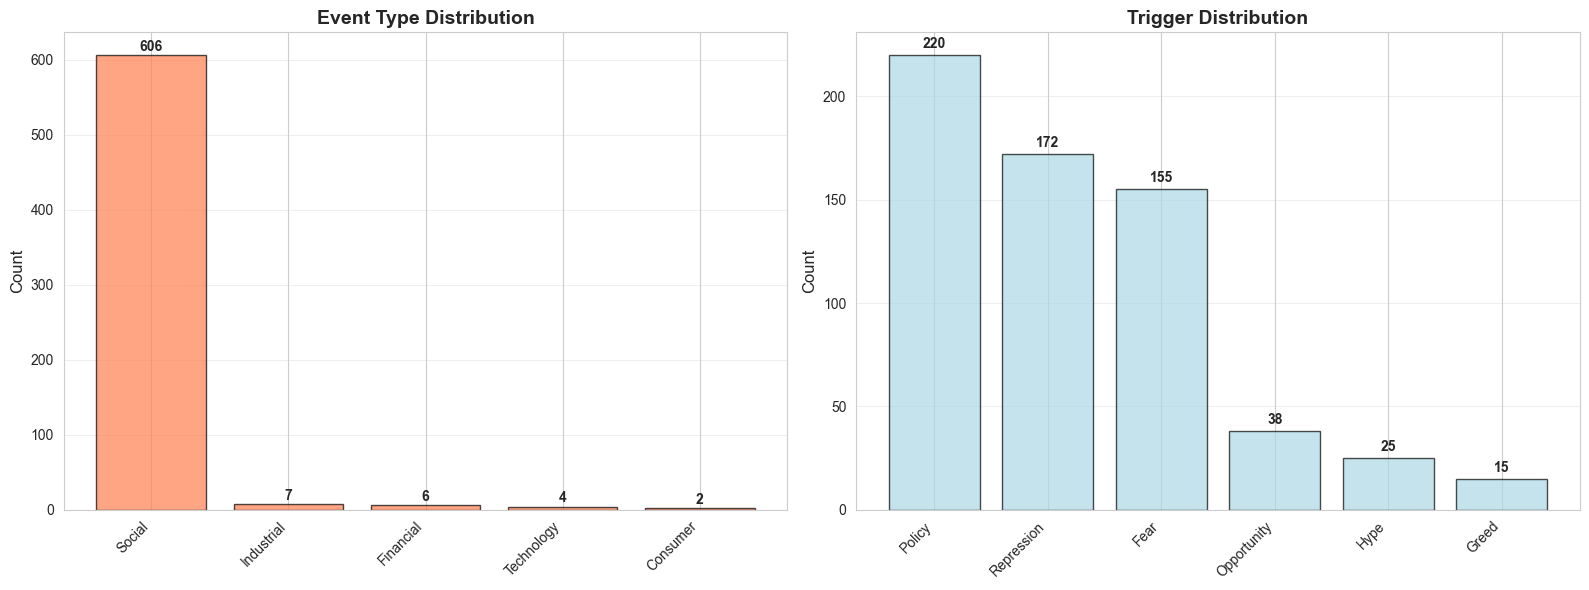


Event Type distribution:
Event Type
Social        606
Industrial      7
Financial       6
Technology      4
Consumer        2
Name: count, dtype: int64

Trigger distribution:
Trigger
Policy         220
Repression     172
Fear           155
Opportunity     38
Hype            25
Greed           15
Name: count, dtype: int64


In [55]:
# Event Type and Trigger distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Event Type
event_type_counts = df['Event Type'].value_counts()
axes[0].bar(range(len(event_type_counts)), event_type_counts.values, 
           color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(event_type_counts)))
axes[0].set_xticklabels(event_type_counts.index, rotation=45, ha='right')
axes[0].set_title('Event Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(event_type_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom', fontweight='bold')

# Trigger
trigger_counts = df['Trigger'].value_counts()
axes[1].bar(range(len(trigger_counts)), trigger_counts.values, 
           color='lightblue', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(trigger_counts)))
axes[1].set_xticklabels(trigger_counts.index, rotation=45, ha='right')
axes[1].set_title('Trigger Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(trigger_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../../dashboards/event_type_trigger_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Event Type and Trigger plot saved to dashboards/event_type_trigger_distribution.png")
plt.show()

print(f"\nEvent Type distribution:")
print(event_type_counts)
print(f"\nTrigger distribution:")
print(trigger_counts)

EVENT TYPE × TRIGGER CROSS-TABULATION

 Trigger     Fear  Greed  Hype  Opportunity  Policy  Repression  All
Event Type                                                         
Consumer       1      0     0            0       1           0    2
Financial      1      1     0            0       4           0    6
Industrial     2      1     0            1       3           0    7
Social       149     13    24           37     211         172  606
Technology     2      0     1            0       1           0    4
All          155     15    25           38     220         172  625

Cross-tabulation heatmap saved to dashboards/event_type_trigger_heatmap.png


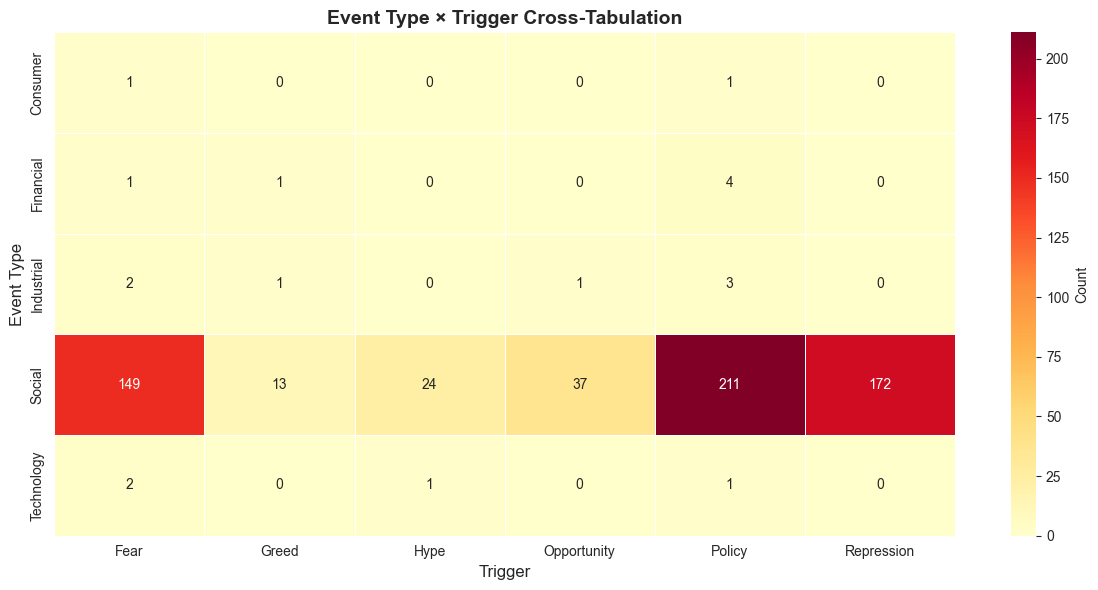

In [56]:
# Event Type × Trigger cross-tabulation
crosstab = pd.crosstab(df['Event Type'], df['Trigger'], margins=True)

print("=" * 80)
print("EVENT TYPE × TRIGGER CROSS-TABULATION")
print("=" * 80)
print("\n", crosstab)

# Heatmap
plt.figure(figsize=(12, 6))
crosstab_no_margins = pd.crosstab(df['Event Type'], df['Trigger'])
sns.heatmap(crosstab_no_margins, annot=True, fmt='d', cmap='YlOrRd', 
           linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Event Type × Trigger Cross-Tabulation', fontsize=14, fontweight='bold')
plt.xlabel('Trigger', fontsize=12)
plt.ylabel('Event Type', fontsize=12)
plt.tight_layout()
plt.savefig('../../dashboards/event_type_trigger_heatmap.png', dpi=300, bbox_inches='tight')
print("\nCross-tabulation heatmap saved to dashboards/event_type_trigger_heatmap.png")
plt.show()

AVERAGE HBI DIMENSIONS BY EVENT TYPE

             Magnitude(M)  Spread(S)  Intensity(I)  Duration(D)  \
Event Type                                                       
Consumer            8.00       4.50          7.00         8.00   
Financial           8.00       6.50          7.17         4.83   
Industrial          7.29       6.14          7.29         6.29   
Social              6.79       6.25          6.75         5.40   
Technology          8.00       7.25          7.75         4.50   

            Outcome/Impact(R)  
Event Type                     
Consumer                 7.00  
Financial                8.67  
Industrial               7.71  
Social                   7.50  
Technology               8.00  

Dimensions by Event Type plot saved to dashboards/hbi_dimensions_by_event_type.png


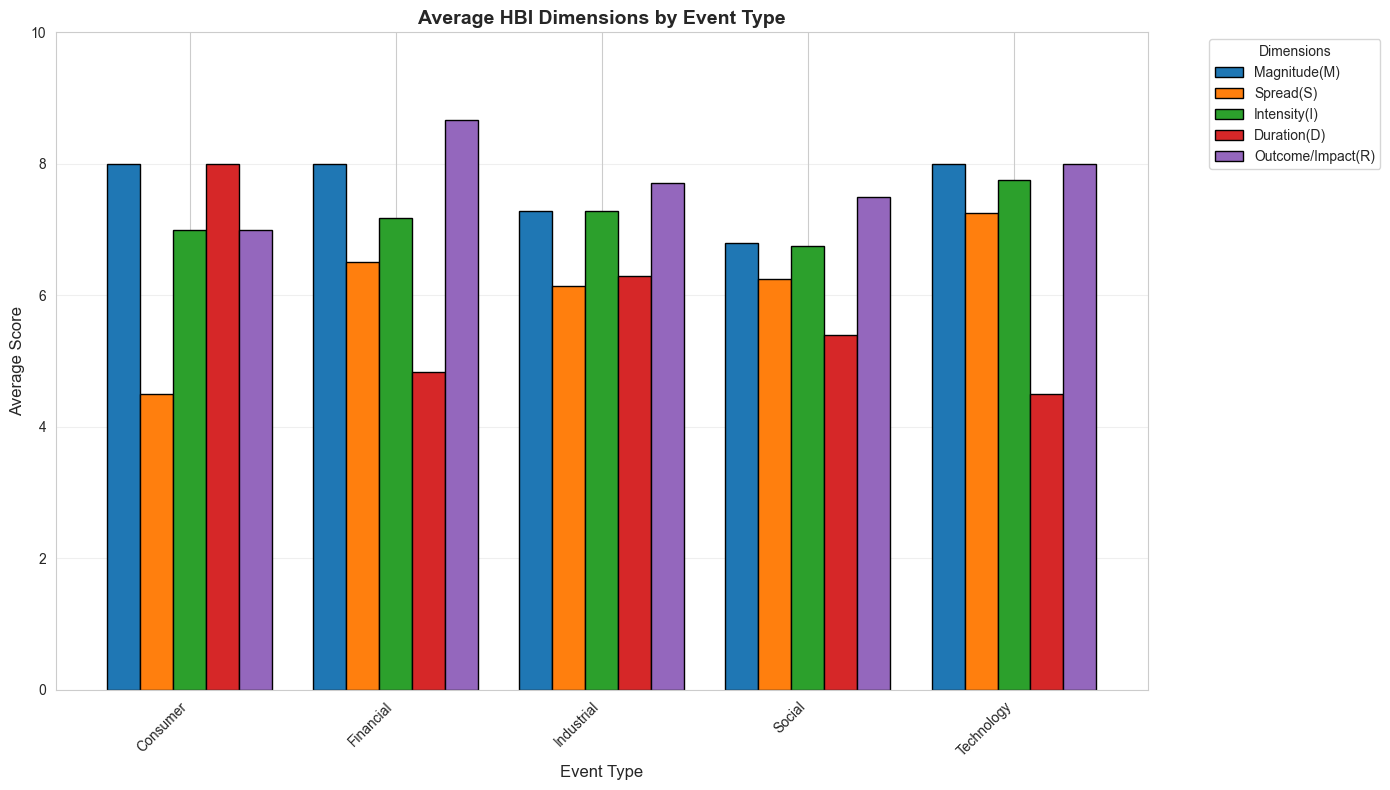

In [57]:
# Average HBI dimensions by Event Type
event_type_stats = df.groupby('Event Type')[dimensions].mean().round(2)

print("=" * 80)
print("AVERAGE HBI DIMENSIONS BY EVENT TYPE")
print("=" * 80)
print("\n", event_type_stats)

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))
event_type_stats.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title('Average HBI Dimensions by Event Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Event Type', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.legend(title='Dimensions', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_by_event_type.png', dpi=300, bbox_inches='tight')
print("\nDimensions by Event Type plot saved to dashboards/hbi_dimensions_by_event_type.png")
plt.show()

AVERAGE HBI DIMENSIONS BY TRIGGER

              Magnitude(M)  Spread(S)  Intensity(I)  Duration(D)  \
Trigger                                                           
Fear                 7.19       6.63          7.24         5.74   
Greed                6.87       5.87          6.47         5.67   
Hype                 7.32       6.56          6.40         4.92   
Opportunity          7.29       6.34          6.68         5.42   
Policy               6.66       6.27          6.33         5.33   
Repression           6.51       5.85          6.99         5.24   

             Outcome/Impact(R)  
Trigger                         
Fear                      7.56  
Greed                     7.40  
Hype                      7.16  
Opportunity               7.95  
Policy                    7.50  
Repression                7.45  

Dimensions by Trigger plot saved to dashboards/hbi_dimensions_by_trigger.png


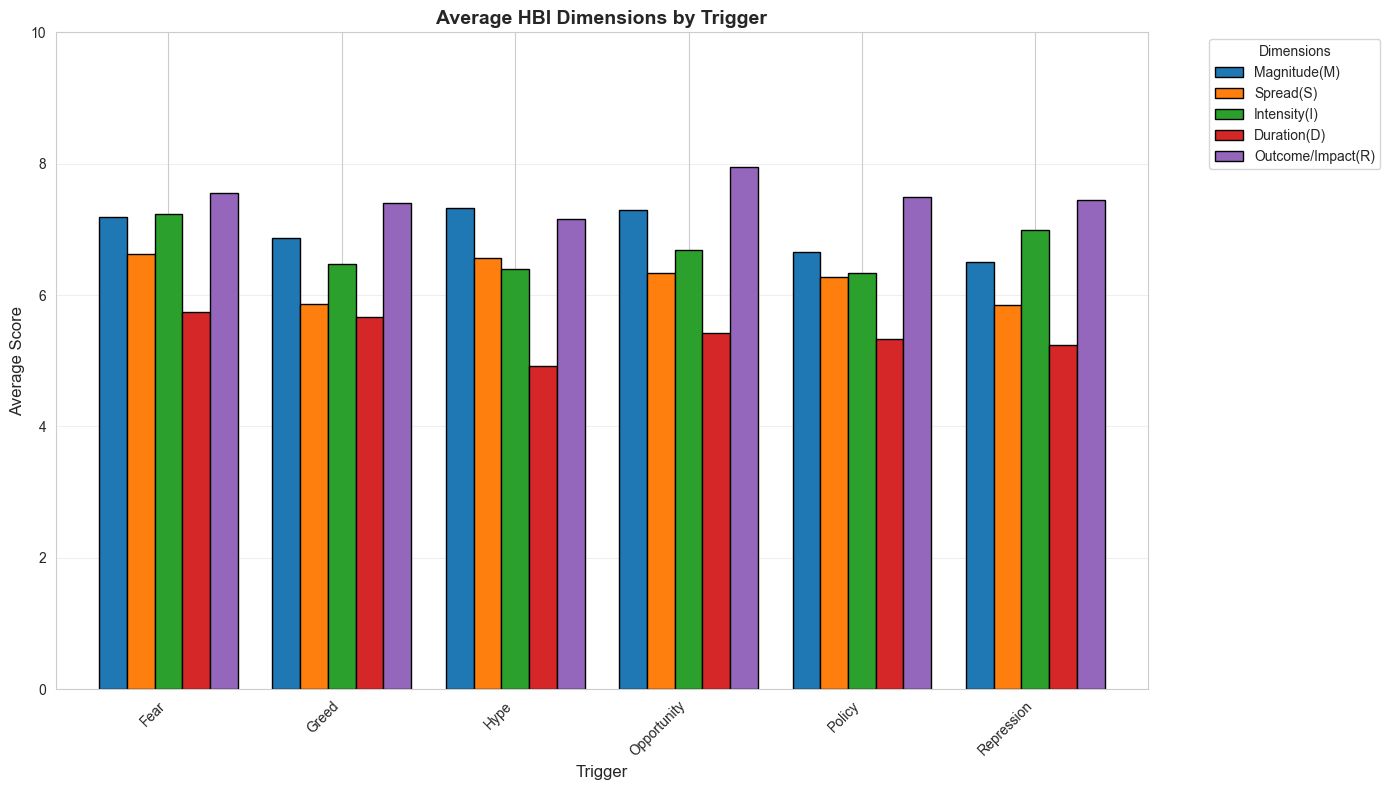

In [58]:
# Average HBI dimensions by Trigger
trigger_stats = df.groupby('Trigger')[dimensions].mean().round(2)

print("=" * 80)
print("AVERAGE HBI DIMENSIONS BY TRIGGER")
print("=" * 80)
print("\n", trigger_stats)

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))
trigger_stats.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title('Average HBI Dimensions by Trigger', fontsize=14, fontweight='bold')
ax.set_xlabel('Trigger', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.legend(title='Dimensions', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_by_trigger.png', dpi=300, bbox_inches='tight')
print("\nDimensions by Trigger plot saved to dashboards/hbi_dimensions_by_trigger.png")
plt.show()

## 8. Correlation Analysis

CORRELATION MATRIX: HBI DIMENSIONS

                    Magnitude(M)  Spread(S)  Intensity(I)  Duration(D)  \
Magnitude(M)              1.000      0.317         0.515        0.256   
Spread(S)                 0.317      1.000         0.193        0.203   
Intensity(I)              0.515      0.193         1.000        0.278   
Duration(D)               0.256      0.203         0.278        1.000   
Outcome/Impact(R)         0.356      0.175         0.345        0.378   

                   Outcome/Impact(R)  
Magnitude(M)                   0.356  
Spread(S)                      0.175  
Intensity(I)                   0.345  
Duration(D)                    0.378  
Outcome/Impact(R)              1.000  

✓ Correlation matrix saved to dashboards/correlation_matrix.png


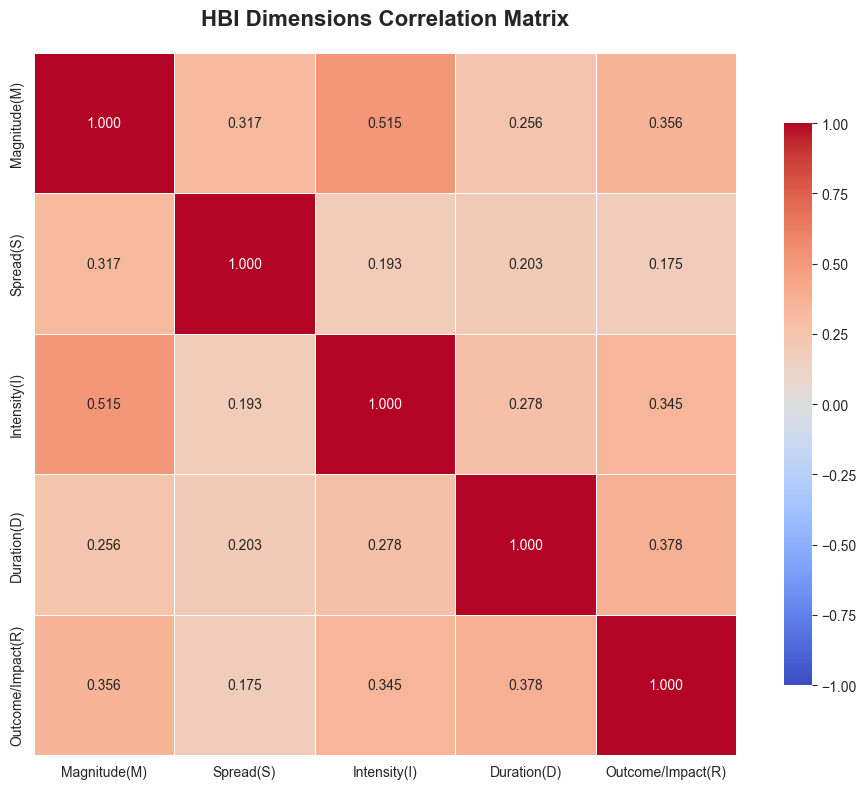


STRONGEST CORRELATIONS (|r| > 0.3)
Intensity(I) × Magnitude(M): 0.515
Outcome/Impact(R) × Duration(D): 0.378
Outcome/Impact(R) × Magnitude(M): 0.356
Outcome/Impact(R) × Intensity(I): 0.345
Spread(S) × Magnitude(M): 0.317


In [59]:
# Correlation matrix for HBI dimensions
corr_matrix = df[dimensions].corr()

print("=" * 80)
print("CORRELATION MATRIX: HBI DIMENSIONS")
print("=" * 80)
print("\n", corr_matrix.round(3))

# Correlation heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            mask=None,
            vmin=-1, vmax=1)

plt.title('HBI Dimensions Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../../dashboards/correlation_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Correlation matrix saved to dashboards/correlation_matrix.png")
plt.show()

# Identify strongest correlations
print("\n" + "=" * 80)
print("STRONGEST CORRELATIONS (|r| > 0.3)")
print("=" * 80)

# Get upper triangle of correlation matrix
corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Flatten and sort
corr_pairs = corr_upper.unstack().dropna().sort_values(key=abs, ascending=False)

# Show correlations above threshold
threshold = 0.3
strong_corr = corr_pairs[abs(corr_pairs) > threshold]

for pair, value in strong_corr.items():
    print(f"{pair[0]} × {pair[1]}: {value:.3f}")

## 9. Segment Analysis

SEGMENT DISTRIBUTION

                            Count  Percentage
Segment                                     
S2 - Emotion-Driven          264       42.24
S4 - Persistent Friction     149       23.84
S1 - Aligned Expansion       148       23.68
S3 - Volatile Expansion       49        7.84
S5 - Low Energy Diffusion      4        0.64

Segment distribution plot saved to dashboards/segment_distribution.png


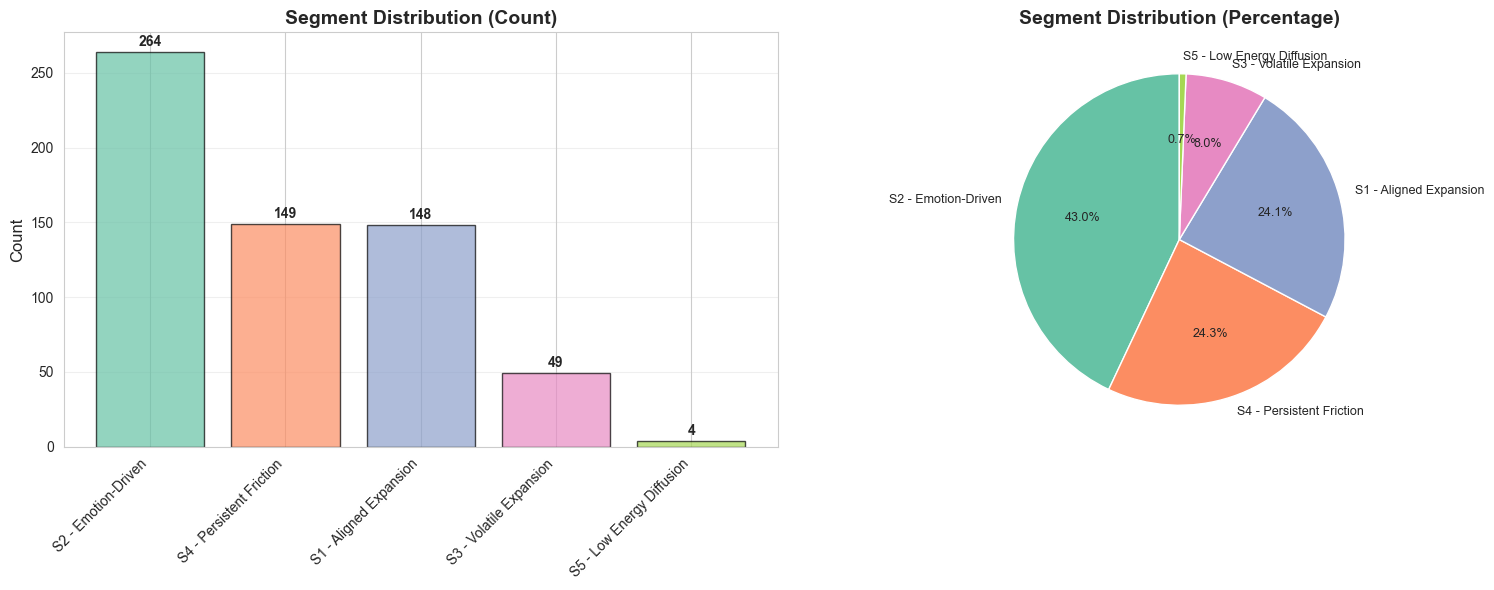

In [60]:
# Segment distribution
segment_counts = df['Segment'].value_counts()
segment_pct = (segment_counts / len(df)) * 100

print("=" * 80)
print("SEGMENT DISTRIBUTION")
print("=" * 80)

segment_summary = pd.DataFrame({
    'Count': segment_counts,
    'Percentage': segment_pct
}).round(2)

print("\n", segment_summary)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = sns.color_palette("Set2", len(segment_counts))
bars = axes[0].bar(range(len(segment_counts)), segment_counts.values, 
                  color=colors, edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(segment_counts)))
axes[0].set_xticklabels(segment_counts.index, rotation=45, ha='right', fontsize=10)
axes[0].set_title('Segment Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(segment_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
           startangle=90, colors=colors, textprops={'fontsize': 9})
axes[1].set_title('Segment Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../../dashboards/segment_distribution.png', dpi=300, bbox_inches='tight')
print("\nSegment distribution plot saved to dashboards/segment_distribution.png")
plt.show()

AVERAGE HBI DIMENSIONS BY SEGMENT

                            Magnitude(M)  Spread(S)  Intensity(I)  Duration(D)  \
Segment                                                                         
S1 - Aligned Expansion             6.39       6.21          5.59         5.58   
S2 - Emotion-Driven                6.94       6.13          7.32         4.37   
S3 - Volatile Expansion            6.10       6.27          5.45         2.41   
S4 - Persistent Friction           7.50       6.74          7.60         8.19   
S5 - Low Energy Diffusion          3.75       4.75          3.00         3.25   

                           Outcome/Impact(R)  
Segment                                       
S1 - Aligned Expansion                  7.21  
S2 - Emotion-Driven                     7.50  
S3 - Volatile Expansion                 6.78  
S4 - Persistent Friction                8.19  
S5 - Low Energy Diffusion               6.00  

Dimensions by Segment plot saved to dashboards/hbi_dimensions_by_s

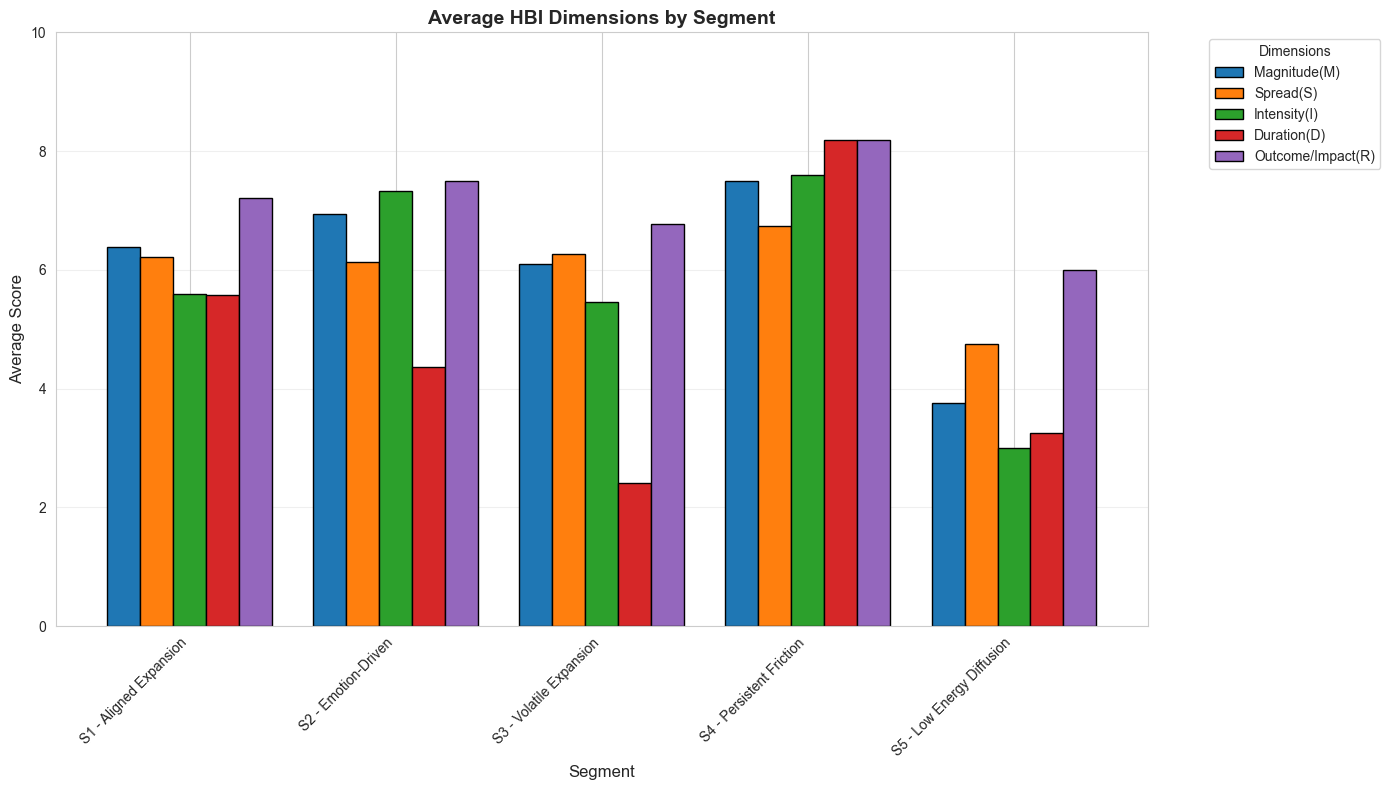

In [61]:
# Average HBI dimensions by Segment
segment_stats = df.groupby('Segment')[dimensions].mean().round(2)

print("=" * 80)
print("AVERAGE HBI DIMENSIONS BY SEGMENT")
print("=" * 80)
print("\n", segment_stats)

# Visualization - Radar chart would be ideal, but bar chart for now
fig, ax = plt.subplots(figsize=(14, 8))
segment_stats.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title('Average HBI Dimensions by Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.legend(title='Dimensions', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_by_segment.png', dpi=300, bbox_inches='tight')
print("\nDimensions by Segment plot saved to dashboards/hbi_dimensions_by_segment.png")
plt.show()

MODE DISTRIBUTION

Co-Present: 28 (4.5%)
Diffusive: 597 (95.5%)

Mode analysis plot saved to dashboards/mode_analysis.png


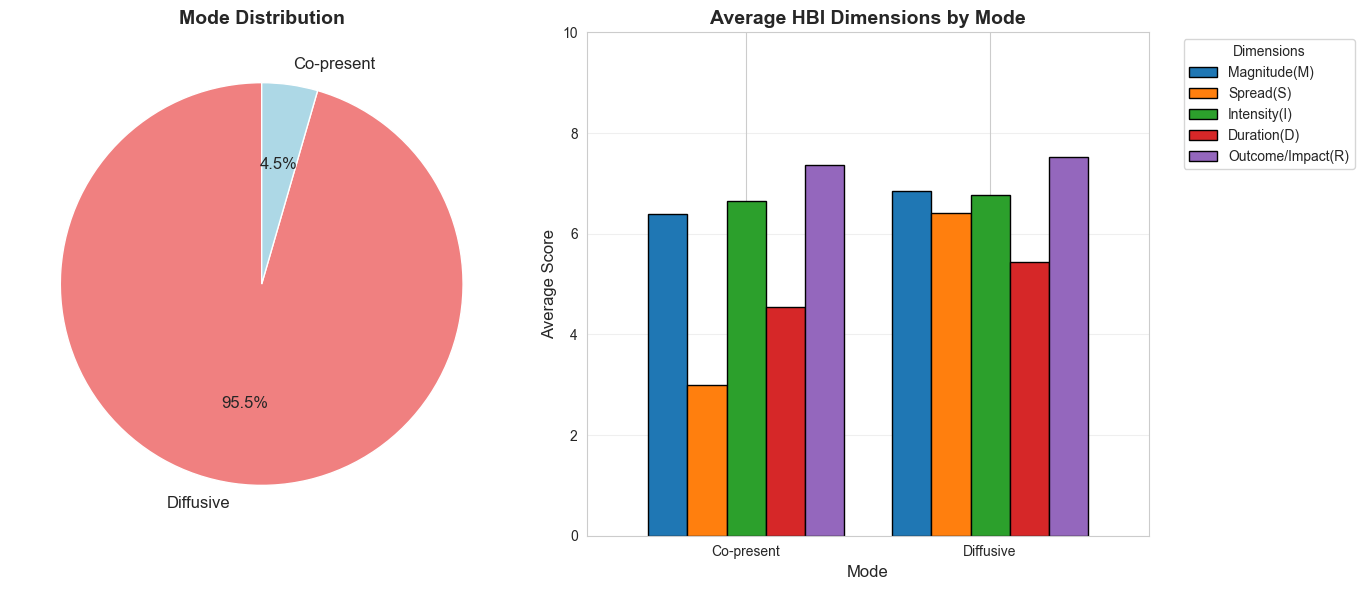


Average dimensions by Mode:
            Magnitude(M)  Spread(S)  Intensity(I)  Duration(D)  \
Mode                                                             
Co-present          6.39        3.0          6.64         4.54   
Diffusive           6.84        6.4          6.77         5.45   

            Outcome/Impact(R)  
Mode                           
Co-present               7.36  
Diffusive                7.52  


In [62]:
# Mode distribution
mode_counts = df['Mode'].value_counts()
mode_pct = (mode_counts / len(df)) * 100

print("=" * 80)
print("MODE DISTRIBUTION")
print("=" * 80)
print(f"\nCo-Present: {mode_counts.get('Co-present', 0)} ({mode_pct.get('Co-present', 0):.1f}%)")
print(f"Diffusive: {mode_counts.get('Diffusive', 0)} ({mode_pct.get('Diffusive', 0):.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors_mode = ['lightcoral', 'lightblue']
axes[0].pie(mode_counts.values, labels=mode_counts.index, autopct='%1.1f%%',
           startangle=90, colors=colors_mode, textprops={'fontsize': 12})
axes[0].set_title('Mode Distribution', fontsize=14, fontweight='bold')

# Average dimensions by mode
mode_stats = df.groupby('Mode')[dimensions].mean()
mode_stats.plot(kind='bar', ax=axes[1], width=0.8, edgecolor='black')
axes[1].set_title('Average HBI Dimensions by Mode', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mode', fontsize=12)
axes[1].set_ylabel('Average Score', fontsize=12)
axes[1].legend(title='Dimensions', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig('../../dashboards/mode_analysis.png', dpi=300, bbox_inches='tight')
print("\nMode analysis plot saved to dashboards/mode_analysis.png")
plt.show()

print(f"\nAverage dimensions by Mode:")
print(mode_stats.round(2))

## 10. Scatter Plot Matrix (Pair Plot)

Pair plot saved to dashboards/hbi_dimensions_pairplot.png


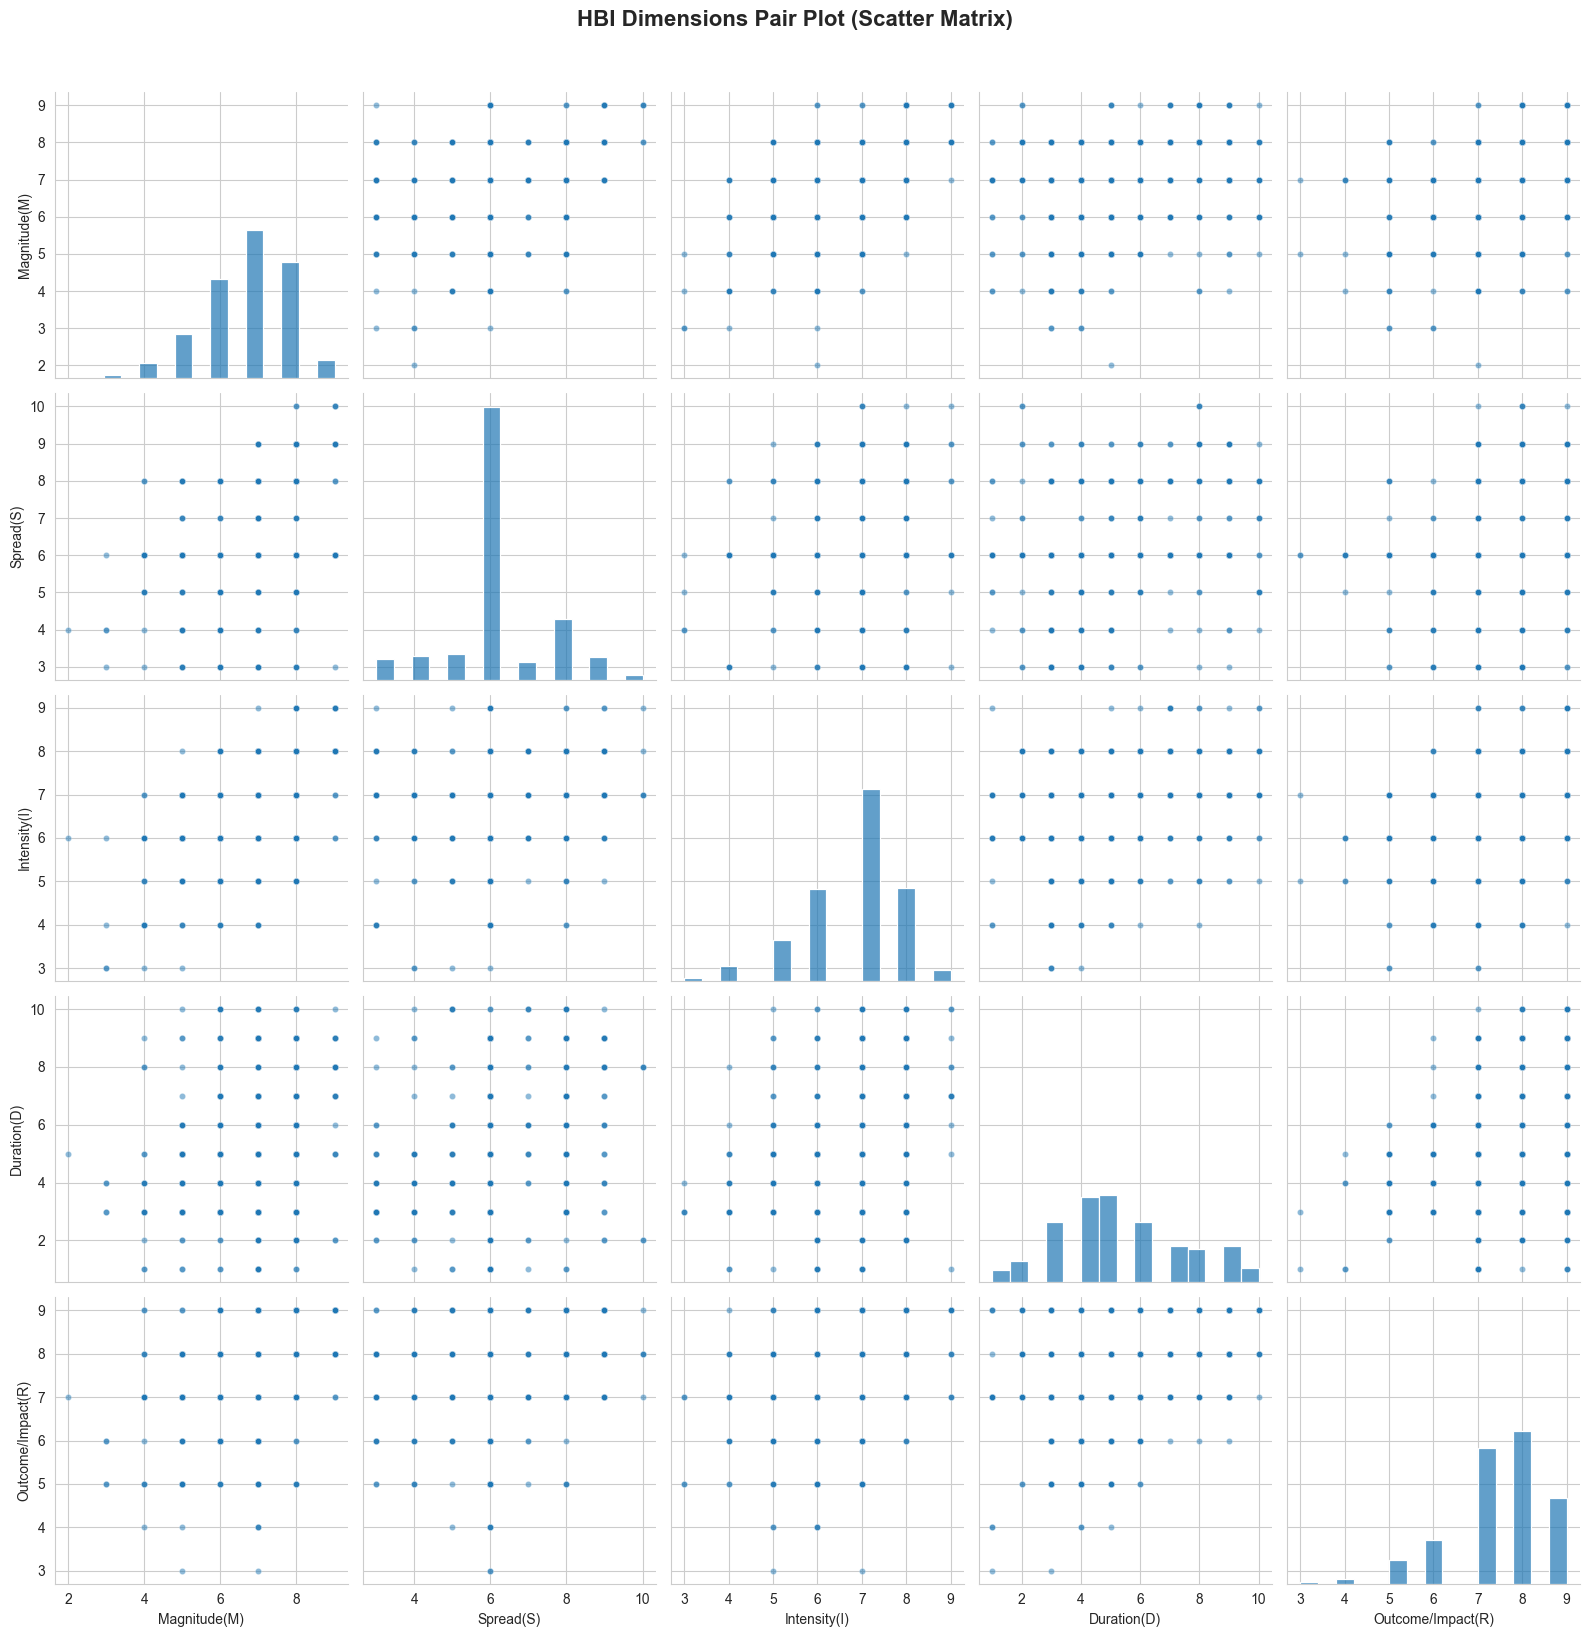

In [63]:
# Scatter plot matrix for HBI dimensions
# Using a subset for better visualization if dataset is large
sample_size = min(500, len(df))
df_sample = df.sample(n=sample_size, random_state=42) if len(df) > 500 else df

# Create pair plot
pairplot = sns.pairplot(df_sample[dimensions], 
                       diag_kind='hist',
                       plot_kws={'alpha': 0.5, 's': 20},
                       diag_kws={'bins': 15, 'alpha': 0.7})

pairplot.fig.suptitle('HBI Dimensions Pair Plot (Scatter Matrix)', 
                      fontsize=16, fontweight='bold', y=1.02)

# Save with larger figure
pairplot.fig.set_size_inches(16, 16)
plt.tight_layout()
plt.savefig('../../dashboards/hbi_dimensions_pairplot.png', dpi=300, bbox_inches='tight')
print("Pair plot saved to dashboards/hbi_dimensions_pairplot.png")
plt.show()

## 11. Summary Statistics by Key Groups

In [64]:
# Summary statistics grouped by Segment, Event Type, and Trigger
print("=" * 80)
print("SUMMARY STATISTICS BY SEGMENT")
print("=" * 80)
print("\n", df.groupby('Segment')[dimensions].agg(['mean', 'std', 'min', 'max']).round(2))

print("\n" + "=" * 80)
print("SUMMARY STATISTICS BY EVENT TYPE")
print("=" * 80)
print("\n", df.groupby('Event Type')[dimensions].agg(['mean', 'std']).round(2))

print("\n" + "=" * 80)
print("SUMMARY STATISTICS BY TRIGGER")
print("=" * 80)
print("\n", df.groupby('Trigger')[dimensions].agg(['mean', 'std']).round(2))

SUMMARY STATISTICS BY SEGMENT

                           Magnitude(M)                 Spread(S)             \
                                  mean   std  min  max      mean   std  min   
Segment                                                                       
S1 - Aligned Expansion            6.39  1.11  4.0  9.0      6.21  1.01  4.0   
S2 - Emotion-Driven               6.94  1.00  4.0  9.0      6.13  1.38  3.0   
S3 - Volatile Expansion           6.10  1.31  4.0  8.0      6.27  0.97  4.0   
S4 - Persistent Friction          7.50  0.91  5.0  9.0      6.74  1.44  3.0   
S5 - Low Energy Diffusion         3.75  0.96  3.0  5.0      4.75  0.96  4.0   

                                Intensity(I)                  Duration(D)  \
                            max         mean   std  min   max        mean   
Segment                                                                     
S1 - Aligned Expansion      9.0         5.59  0.61  4.0   6.0        5.58   
S2 - Emotion-Driven        

## 12. Key Insights Summary

In [65]:
# Generate summary insights
print("=" * 80)
print("EDA KEY INSIGHTS SUMMARY")
print("=" * 80)

print(f"\nDATASET OVERVIEW:")
print(f"  • Total Events: {len(df):,}")
print(f"  • Time Period: {df['Year'].min()} - {df['Year'].max()}")
print(f"  • No Missing Values: ✅")

print(f"\nGEOGRAPHIC DISTRIBUTION:")
top_continent = df['Continent'].value_counts().index[0]
top_country = df['Country'].value_counts().index[0]
print(f"  • Most Events - Continent: {top_continent} ({df['Continent'].value_counts().iloc[0]} events)")
print(f"  • Most Events - Country: {top_country} ({df['Country'].value_counts().iloc[0]} events)")

print(f"\nHBI DIMENSIONS AVERAGES:")
for dim in dimensions:
    avg = df[dim].mean()
    print(f"  • {dim}: {avg:.2f}")

print(f"\nCATEGORICAL DISTRIBUTION:")
print(f"  • Most Common Event Type: {df['Event Type'].value_counts().index[0]} ({df['Event Type'].value_counts().iloc[0]} events)")
print(f"  • Most Common Trigger: {df['Trigger'].value_counts().index[0]} ({df['Trigger'].value_counts().iloc[0]} events)")

print(f"\nSEGMENTATION:")
print(f"  • Most Common Segment: {df['Segment'].value_counts().index[0]} ({df['Segment'].value_counts().iloc[0]} events)")
print(f"  • Mode Distribution: Co-present: {df['Mode'].value_counts().get('Co-present', 0)}, Diffusive: {df['Mode'].value_counts().get('Diffusive', 0)}")

print(f"\nCORRELATIONS:")
# Get top correlation
corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = corr_upper.unstack().dropna().sort_values(key=abs, ascending=False)
if len(corr_pairs) > 0:
    top_corr_pair = corr_pairs.index[0]  # Get the index (tuple of dimension names)
    top_corr_value = corr_pairs.iloc[0]  # Get the correlation value
    print(f"  • Strongest Correlation: {top_corr_pair[0]} × {top_corr_pair[1]}: {top_corr_value:.3f}")

print("\n" + "=" * 80)
print("EDA Analysis Complete!")
print("=" * 80)

EDA KEY INSIGHTS SUMMARY

DATASET OVERVIEW:
  • Total Events: 625
  • Time Period: 1925 - 2025
  • No Missing Values: ✅

GEOGRAPHIC DISTRIBUTION:
  • Most Events - Continent: Australia/Oceania (105 events)
  • Most Events - Country: United States (94 events)

HBI DIMENSIONS AVERAGES:
  • Magnitude(M): 6.82
  • Spread(S): 6.25
  • Intensity(I): 6.76
  • Duration(D): 5.40
  • Outcome/Impact(R): 7.51

CATEGORICAL DISTRIBUTION:
  • Most Common Event Type: Social (606 events)
  • Most Common Trigger: Policy (220 events)

SEGMENTATION:
  • Most Common Segment: S2 - Emotion-Driven (264 events)
  • Mode Distribution: Co-present: 28, Diffusive: 597

CORRELATIONS:
  • Strongest Correlation: Intensity(I) × Magnitude(M): 0.515

EDA Analysis Complete!
